In [1]:
import cogsworth
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import gala.dynamics as gd
import gala.potential as gp
from gala.units import galactic
from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import interp1d
from astropy.coordinates import SkyCoord
from scipy.ndimage import gaussian_filter
import seaborn as sns

import sys
sys.path.append('../src')
import plotting, helpers
from importlib import reload

%config InlineBackend.figure_format = 'retina'


pd.options.display.max_columns = 999

plt.rc('font', family='serif')
plt.rcParams['text.usetex'] = False
fs = 24

# update various fontsizes to match
params = {'figure.figsize': (12, 8),
          'legend.fontsize': 0.7*fs,
          'legend.title_fontsize': 0.8*fs,
          'axes.labelsize': fs,
          'xtick.labelsize': 0.9 * fs,
          'ytick.labelsize': 0.9 * fs,
          'axes.linewidth': 1.1,
          'xtick.major.size': 7,
          'xtick.minor.size': 4,
          'ytick.major.size': 7,
          'ytick.minor.size': 4}
plt.rcParams.update(params)

# Load data

In [2]:
singles = cogsworth.pop.load("/mnt/ceph/users/twagg/underworld/singles", parts=[])
binaries = cogsworth.pop.load("/mnt/ceph/users/twagg/underworld/binaries", parts=[])

/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/site-packages/gala/potential/potential/builtin/special.py:257: GalaFutureWarning: The MilkyWayPotential2022 class will be deprecated soon. Instead, use: MilkyWayPotential(version="v2") to get what is currently the MilkyWayPotential2022 class. Or, to always use the latest Milky Way model in Gala, you can call the class with no arguments MilkyWayPotential() or specify MilkyWayPotential(version="latest")
  warnings.warn(
/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/site-packages/gala/potential/potential/builtin/special.py:257: GalaFutureWarning: The MilkyWayPotential2022 class will be deprecated soon. Instead, use: MilkyWayPotential(version="v2") to get what is currently the MilkyWayPotential2022 class. Or, to always use the latest Milky Way model in Gala, you can call the class with no arguments MilkyWayPotential() or specify MilkyWayPotential(version="latest")
  warnings.warn(


In [3]:
singles.label = "Singles"
singles.colour = "darkgrey"
binaries.label = "Binaries"
binaries.colour = "#96B73B"

for pop in [singles, binaries]:
    pop.bpp["row_num"] = np.arange(len(pop.bpp))

# Totals

In [4]:
scale_up = 6e10 / binaries.mass_binaries
scale_up

np.float64(3307.606976577281)

Singles
  Total: 195100, NSs: 143842, BHs: 51258
Binaries
  Total: 200093, NSs: 144806, BHs: 55287


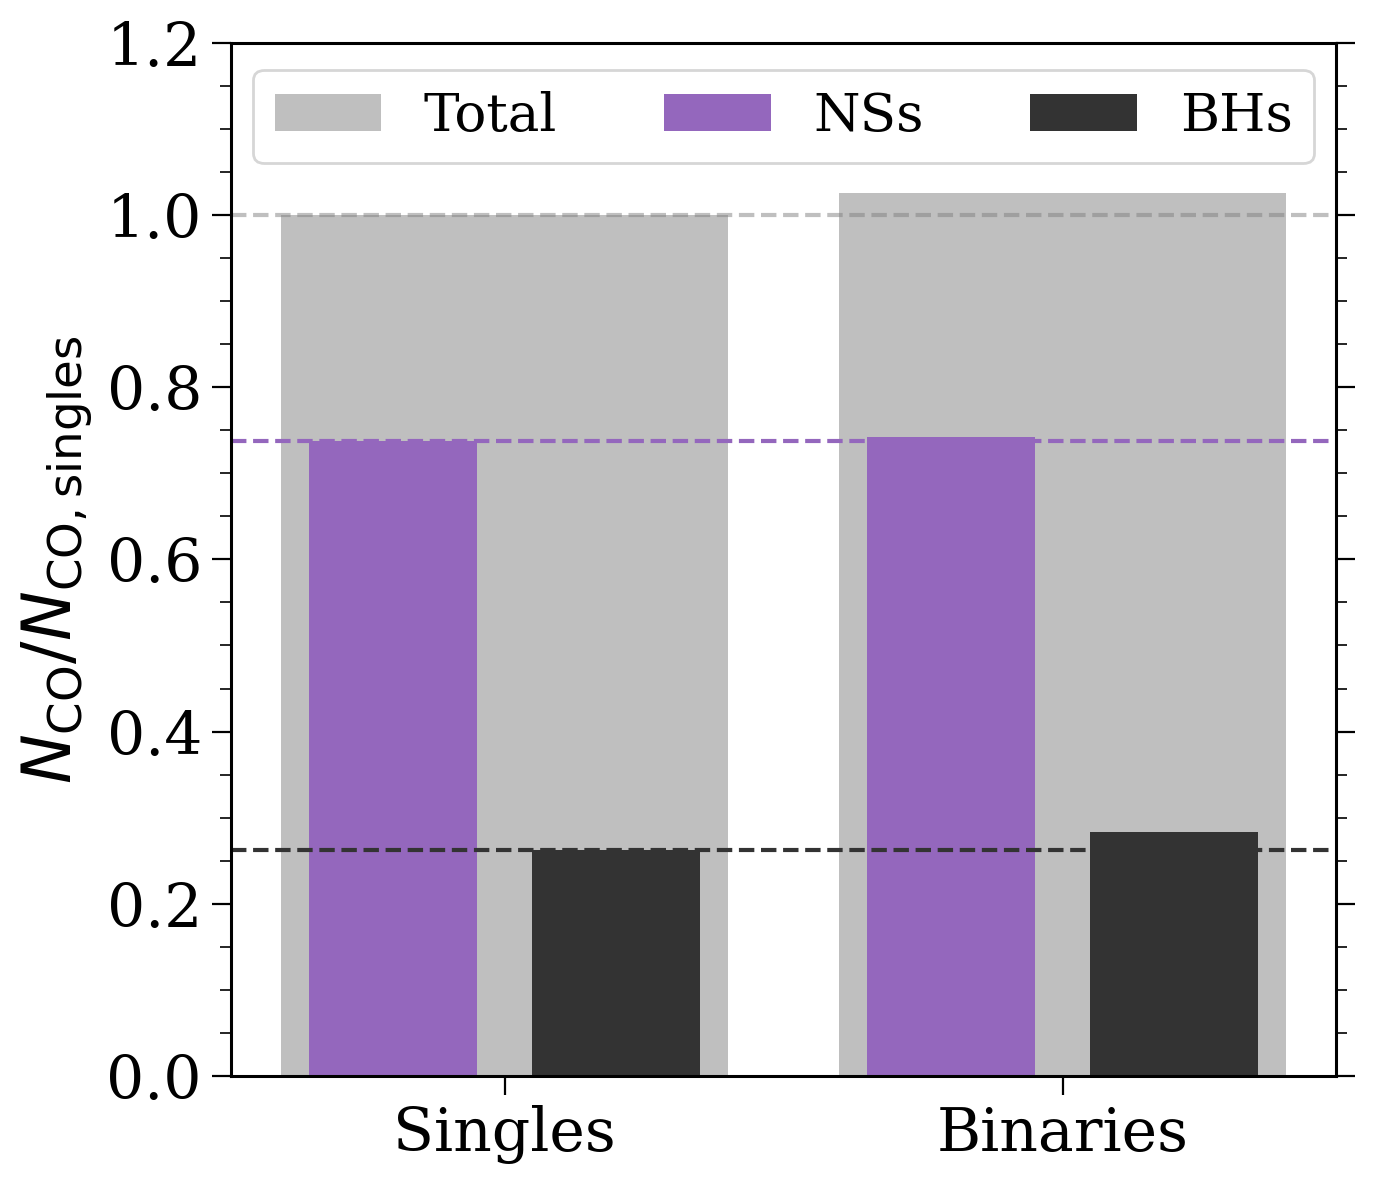

In [5]:
fig, ax = plt.subplots(figsize=(7, 6))

total_single_cos = None

for i, pop in enumerate([singles, binaries]):
    n_ns = (pop.final_bpp["kstar_1"] == 13).sum() + (pop.final_bpp["kstar_2"] == 13).sum()
    n_bh = (pop.final_bpp["kstar_1"] == 14).sum() + (pop.final_bpp["kstar_2"] == 14).sum()
    print(f"{pop.label}\n  Total: {n_ns + n_bh}, NSs: {n_ns}, BHs: {n_bh}")

    if total_single_cos is None and pop.label == "Singles":
        total_single_cos = n_ns + n_bh

    ax.bar(i, (n_ns + n_bh) / total_single_cos, label="Total" if i == 0 else None, color="grey", alpha=0.5)
    ax.bar(i - 0.2, n_ns / total_single_cos, width=0.3, label="NSs" if i == 0 else None, color="tab:purple")
    ax.bar(i + 0.2, n_bh / total_single_cos, width=0.3, label="BHs" if i == 0 else None, color="#333")

    if i == 0:
        ax.axhline((n_ns + n_bh) / total_single_cos, color="grey", alpha=0.5, ls='--')
        ax.axhline(n_ns / total_single_cos, color="tab:purple", ls='--')
        ax.axhline(n_bh / total_single_cos, color="#333", ls='--')

pops = [singles, binaries]
ax.set_xticks(range(len(pops)), [pop.label for pop in pops])
ax.set_ylabel(r"$N_{\rm CO} / N_{\rm CO, singles}$")
ax.legend(ncol=3, loc='upper center', fontsize=0.8*fs)

ax.set(
    ylim=(0, 1.2),
)

ax.yaxis.set_major_locator(mpl.ticker.MultipleLocator(0.2))
ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.05))

# show yticks on both sides
ax.yaxis.set_ticks_position('both')

plt.tight_layout()
plt.show()

## Takeaways

Binaries are produce slightly more compact objects?

- Mergers increasing the amount that can reach core-collapse?

Binaries don't have a strong effect on the NSs, but slightly increase the BH total.

- Hypothesis: Stars can now become NSs, some NSs can now become BHs, BHs only go up


## It's mergers right?

Mergers can both increase and decrease the total number of COs formed from a given total stellar mass since:

1. A merger of two stars that could both have become COs decreases your CO count by 1
2. A merger of two low mass stars that couldn't become COs without merging increases your count by 1

Arguably from the IMF, the latter should be more common and so binaries should make many more COs

In [6]:
stellar_merger_nums = binaries.bpp[(
    (
        (binaries.bpp['kstar_1'] == 15) & (binaries.bpp["kstar_2"] < 13)
    ) | (
        (binaries.bpp['kstar_2'] == 15) & (binaries.bpp["kstar_1"] < 13)
    )
)].drop_duplicates(subset="bin_num", keep="first")["bin_num"]

In [7]:
merger_inits = binaries.initC.loc[stellar_merger_nums]

In [17]:
bh_bin_nums = binaries.final_bpp["bin_num"][(binaries.final_bpp["kstar_1"] == 14) | (binaries.final_bpp["kstar_2"] == 14)].values

In [20]:
len(bh_bin_nums)

50339

In [32]:
merger_bhs = binaries.final_bpp.loc[merger_inits["bin_num"]][["kstar_1", "kstar_2"]].min(axis=1) == 14

In [22]:
merger_inits["bin_num"].isin(bh_bin_nums)

2         False
3         False
4         False
8         False
19        False
          ...  
317178     True
317184     True
317192    False
317194    False
317198     True
Name: bin_num, Length: 137231, dtype: bool

In [9]:
min_exploding_mass_df = pd.read_hdf("~/ceph/underworld/cosmic_explode_crit.h5", key="min_exploding_mass")
min_exploding_mass = interp1d(min_exploding_mass_df["metallicity"], min_exploding_mass_df["mass_1"])

min_bh_mass_df = pd.read_hdf("~/ceph/underworld/cosmic_bh_crit.h5", key="min_bh_mass")
min_bh_mass = interp1d(min_bh_mass_df["metallicity"], min_bh_mass_df["mass_1"])

In [10]:
min_exploding_mass(merger_inits["metallicity"].values)

array([7.8273948 , 7.03582541, 7.10453943, ..., 7.        , 7.25155802,
       6.54063485], shape=(137231,))

In [11]:
LIM = 7.5
high_mass_mergers = (merger_inits["mass_1"] >= LIM) & (merger_inits["mass_2"] >= LIM)
low_mass_mergers = (merger_inits["mass_1"] < LIM) & (merger_inits["mass_2"] < LIM)

print(f"Total mergers: {len(merger_inits)}")
print(f"  High mass mergers: {high_mass_mergers.sum()} ({high_mass_mergers.sum() / len(merger_inits):.2%})")
print(f"  Low mass mergers: {low_mass_mergers.sum()} ({low_mass_mergers.sum() / len(merger_inits):.2%})")

Total mergers: 137231
  High mass mergers: 40927 (29.82%)
  Low mass mergers: 49154 (35.82%)


In [ ]:
LIM = min_exploding_mass(merger_inits["metallicity"].values)
high_mass_mergers = (merger_inits["mass_1"] >= LIM) & (merger_inits["mass_2"] >= LIM)
low_mass_mergers = (merger_inits["mass_1"] < LIM) & (merger_inits["mass_2"] < LIM)

print(f"Total mergers: {len(merger_inits)}")
print(f"  High mass mergers: {high_mass_mergers.sum()} ({high_mass_mergers.sum() / len(merger_inits):.2%})")
print(f"  Low mass mergers: {low_mass_mergers.sum()} ({low_mass_mergers.sum() / len(merger_inits):.2%})")

Total mergers: 137231
  High mass mergers: 42492 (30.96%)
  Low mass mergers: 46272 (33.72%)


In [34]:
n_bh

np.int64(55287)

In [33]:
LIM = min_bh_mass(merger_inits[merger_bhs]["metallicity"].values)
high_mass_mergers = (merger_inits[merger_bhs]["mass_1"] >= LIM) & (merger_inits[merger_bhs]["mass_2"] >= LIM)
low_mass_mergers = (merger_inits[merger_bhs]["mass_1"] < LIM) & (merger_inits[merger_bhs]["mass_2"] < LIM)

print(f"Total mergers: {len(merger_inits[merger_bhs])}")
print(f"  High mass mergers: {high_mass_mergers.sum()} ({high_mass_mergers.sum() / len(merger_inits[merger_bhs]):.2%})")
print(f"  Low mass mergers: {low_mass_mergers.sum()} ({low_mass_mergers.sum() / len(merger_inits[merger_bhs]):.2%})")

Total mergers: 37674
  High mass mergers: 9883 (26.23%)
  Low mass mergers: 14700 (39.02%)


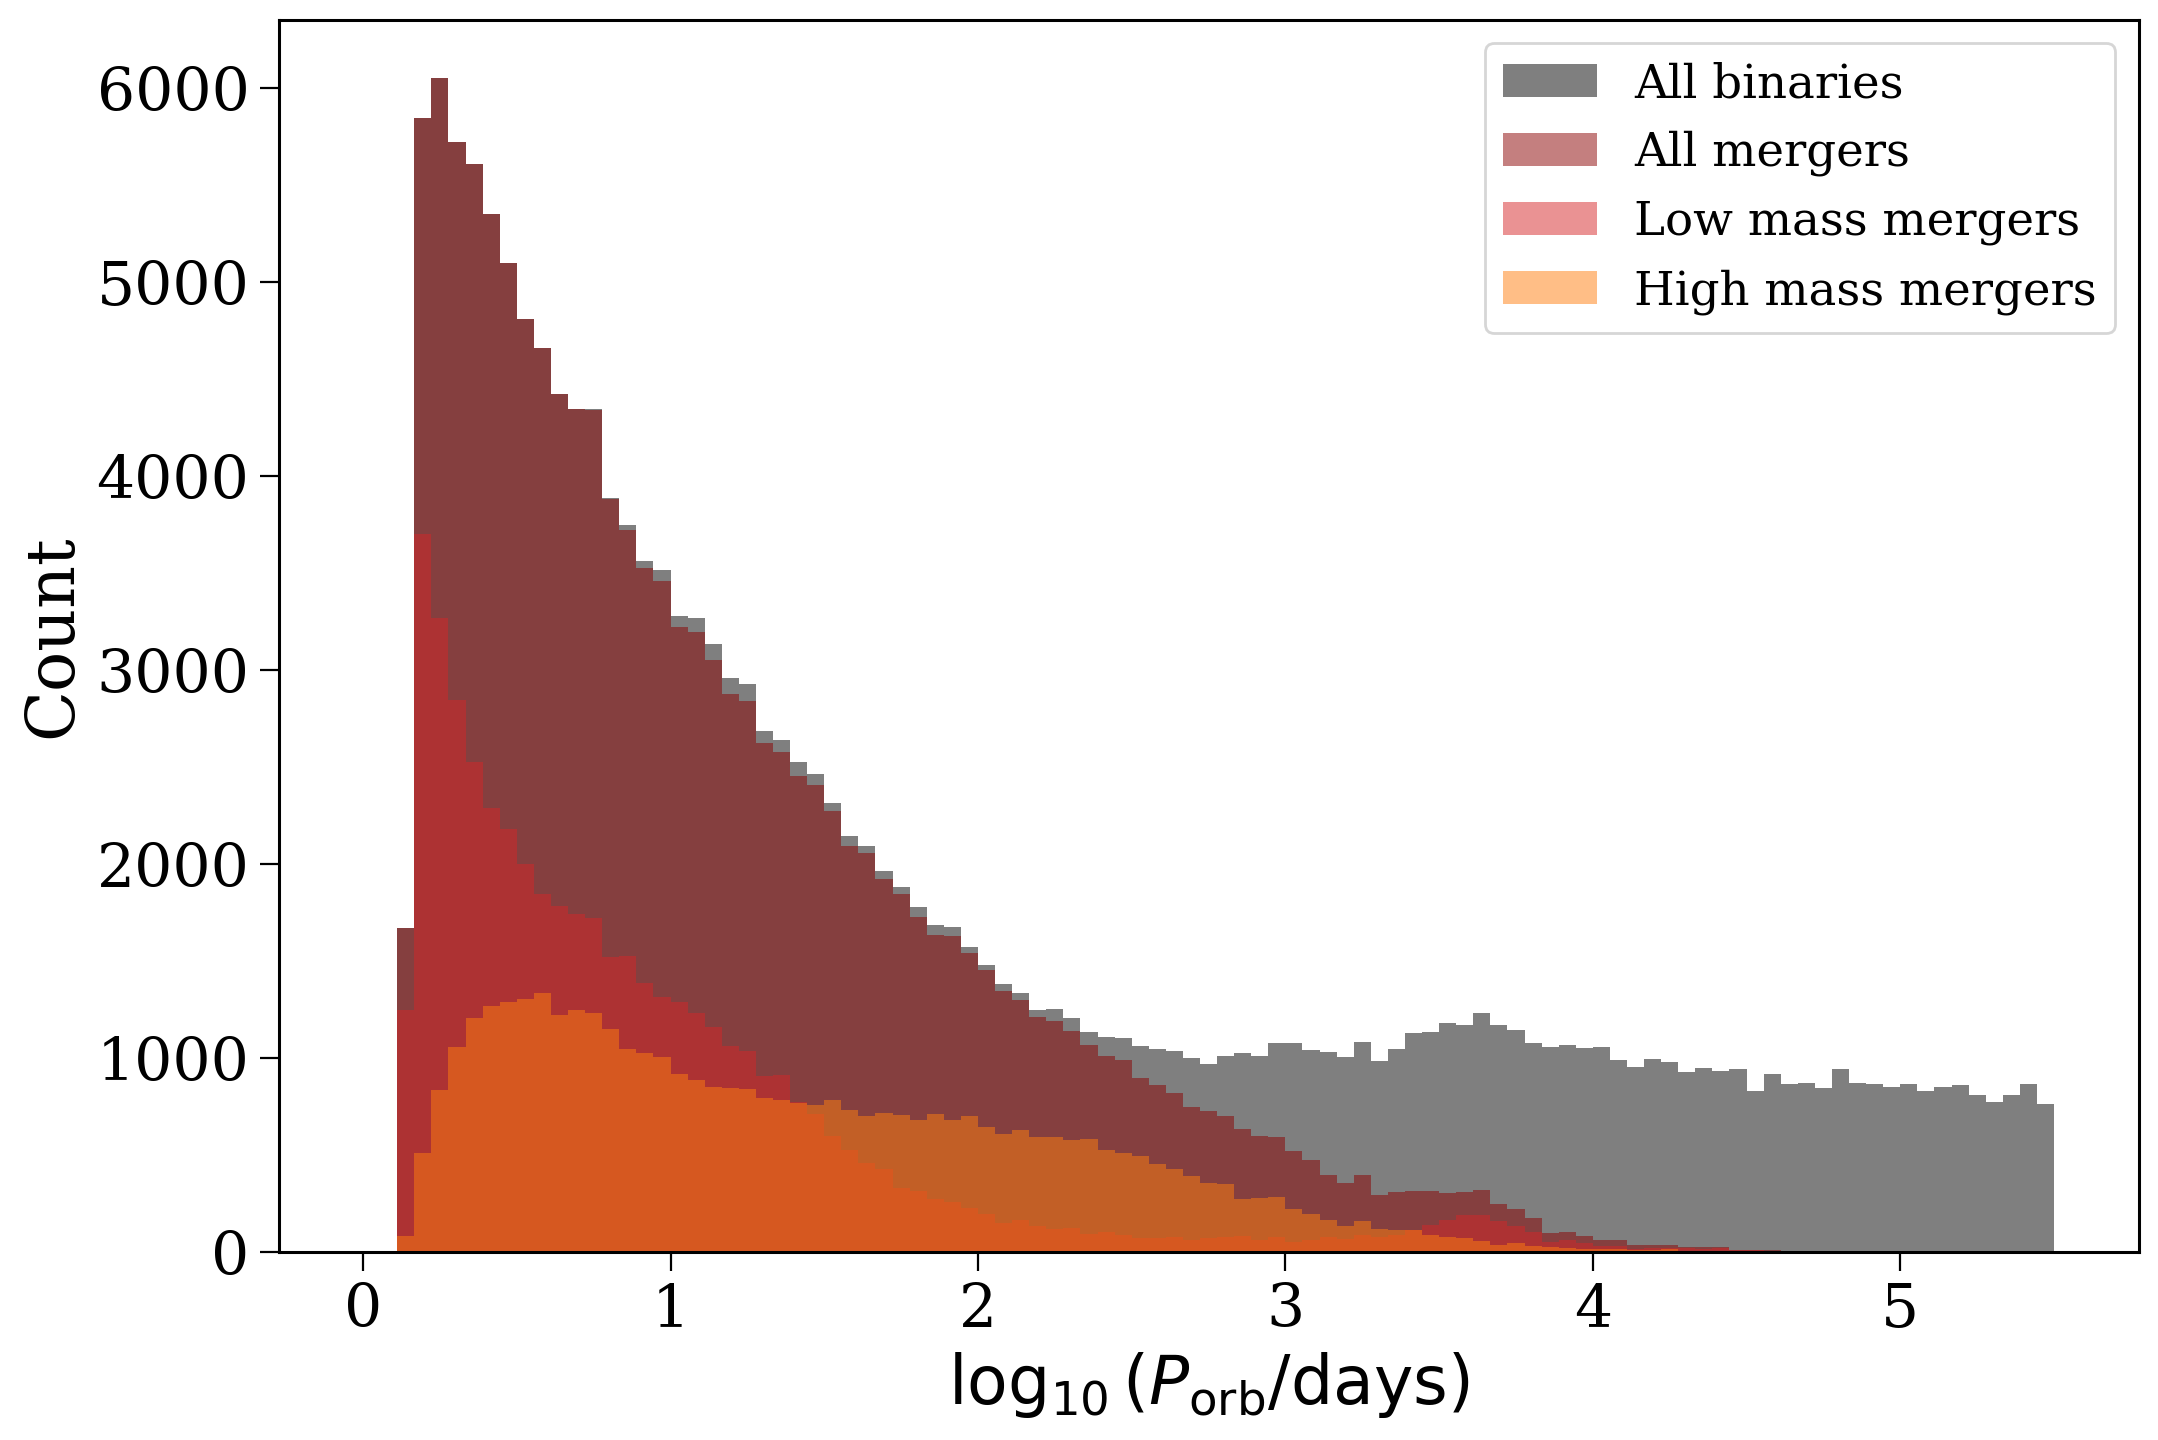

In [11]:
fig, ax = plt.subplots()

ax.hist(np.log10(binaries.initC["porb"]), bins=np.linspace(0, 5.5, 100), alpha=0.5, label="All binaries", color="black")
ax.hist(np.log10(merger_inits["porb"]), bins=np.linspace(0, 5.5, 100), alpha=0.5, label="All mergers", color="darkred")
ax.hist(np.log10(merger_inits["porb"][low_mass_mergers]), bins=np.linspace(0, 5.5, 100), alpha=0.5, label="Low mass mergers", color="tab:red")
ax.hist(np.log10(merger_inits["porb"][high_mass_mergers]), bins=np.linspace(0, 5.5, 100), alpha=0.5, label="High mass mergers", color="tab:orange")

ax.set(
    xlabel=r"$\log_{10}(P_{\rm orb} / \mathrm{days})$",
    ylabel="Count",
)
ax.legend()
plt.show()

# Mass distributions

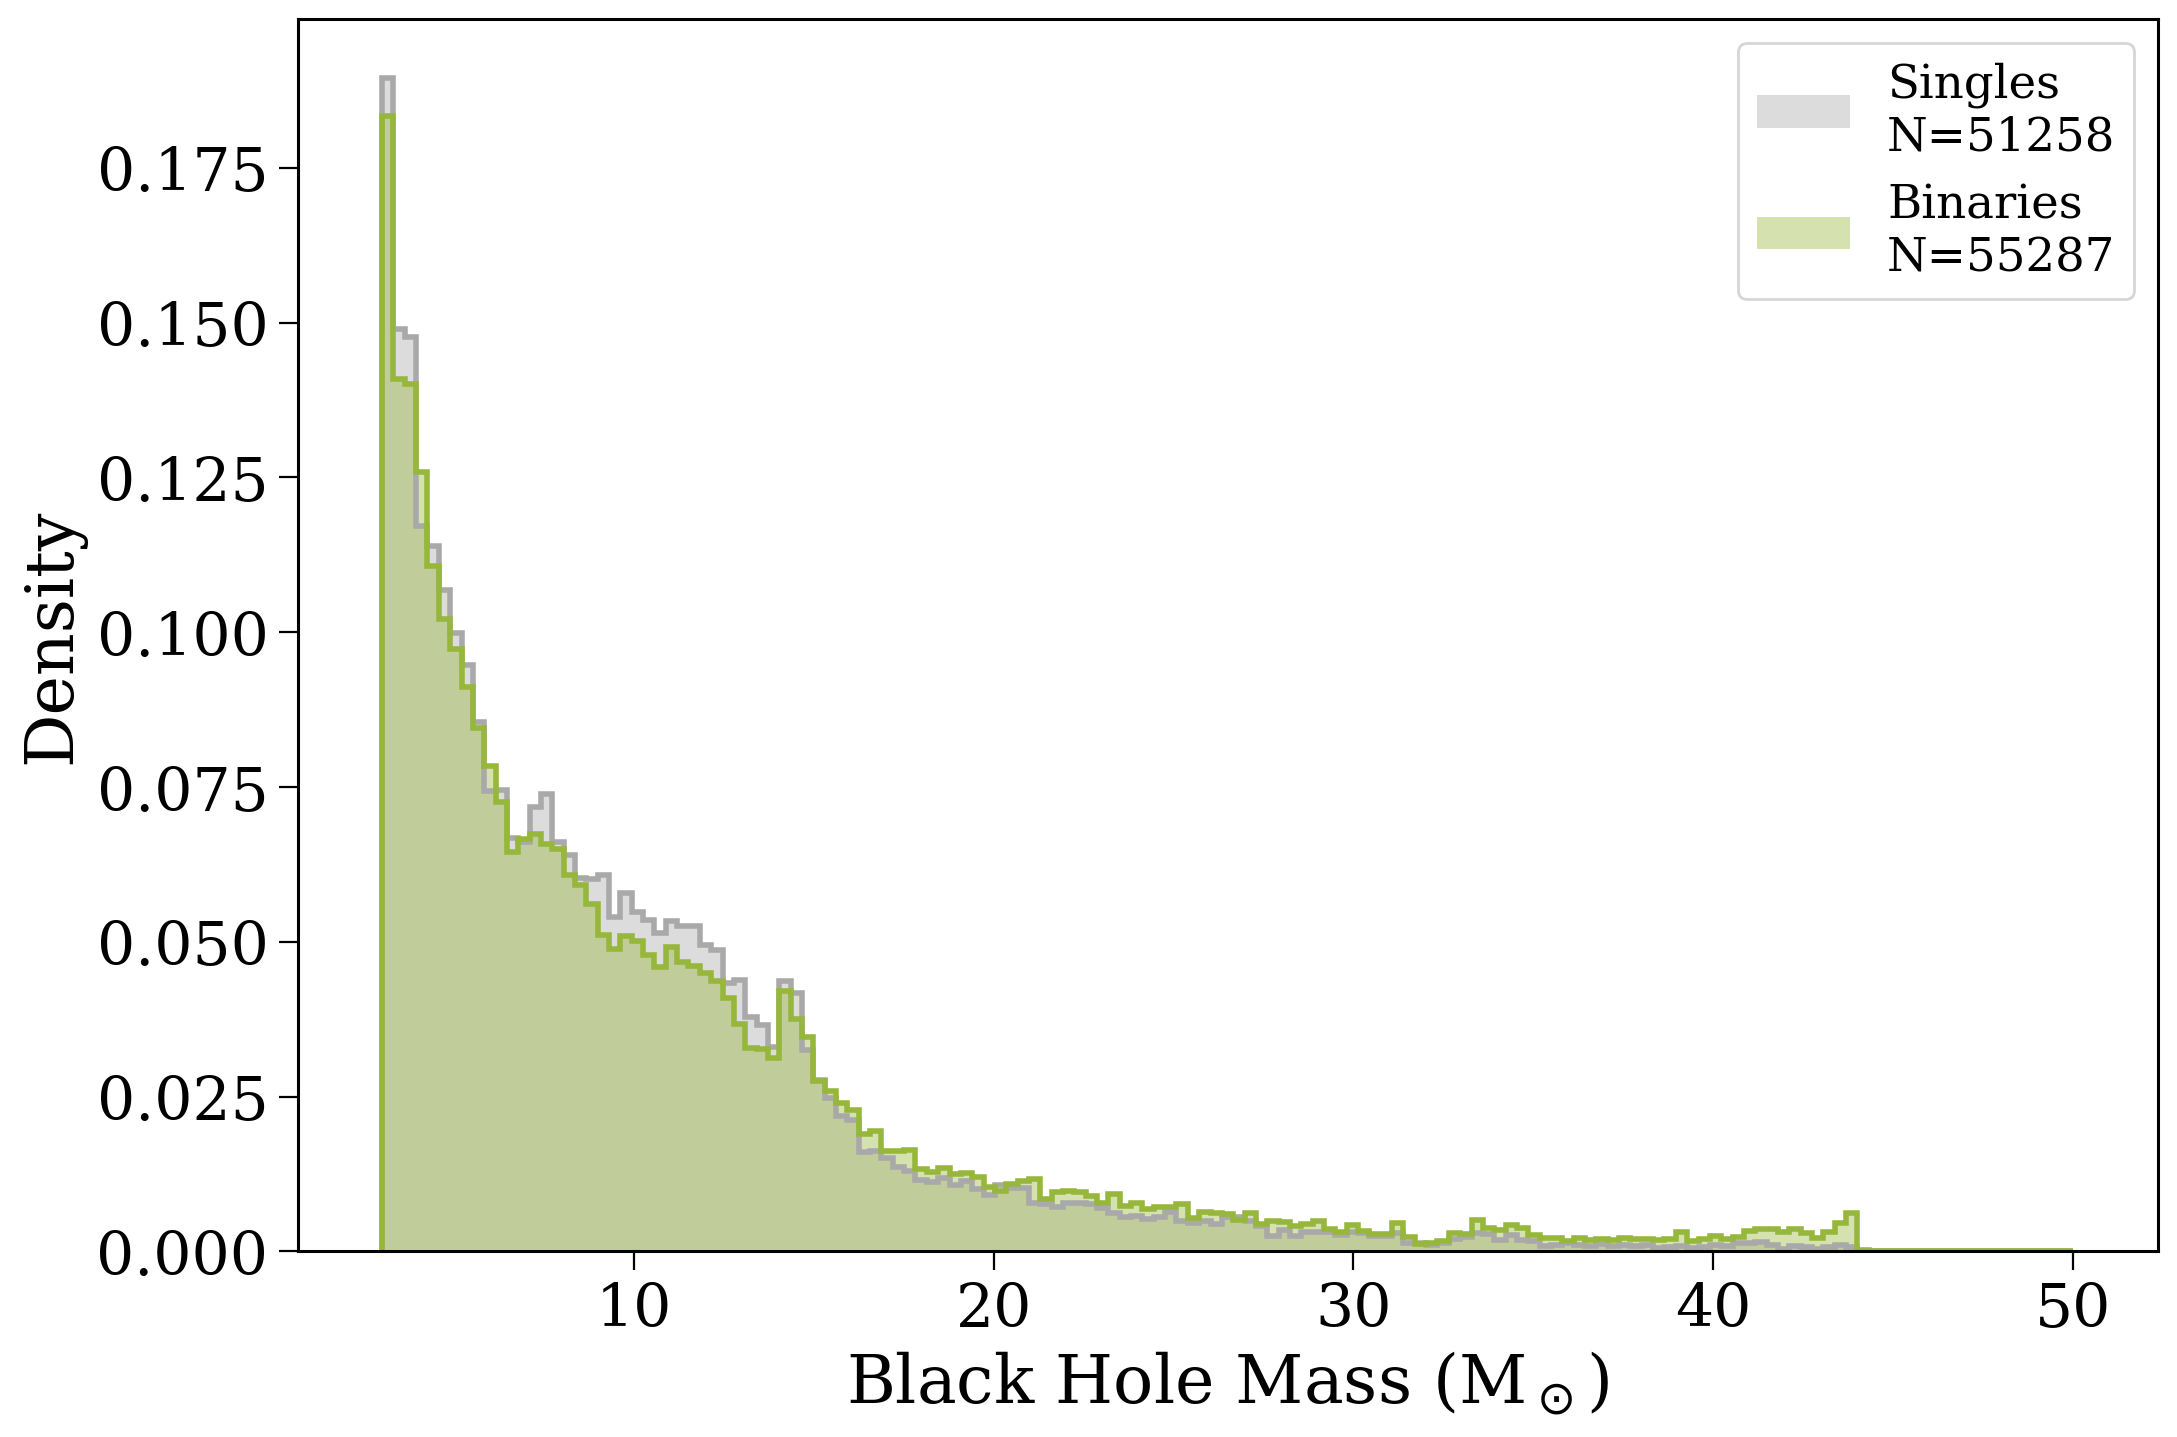

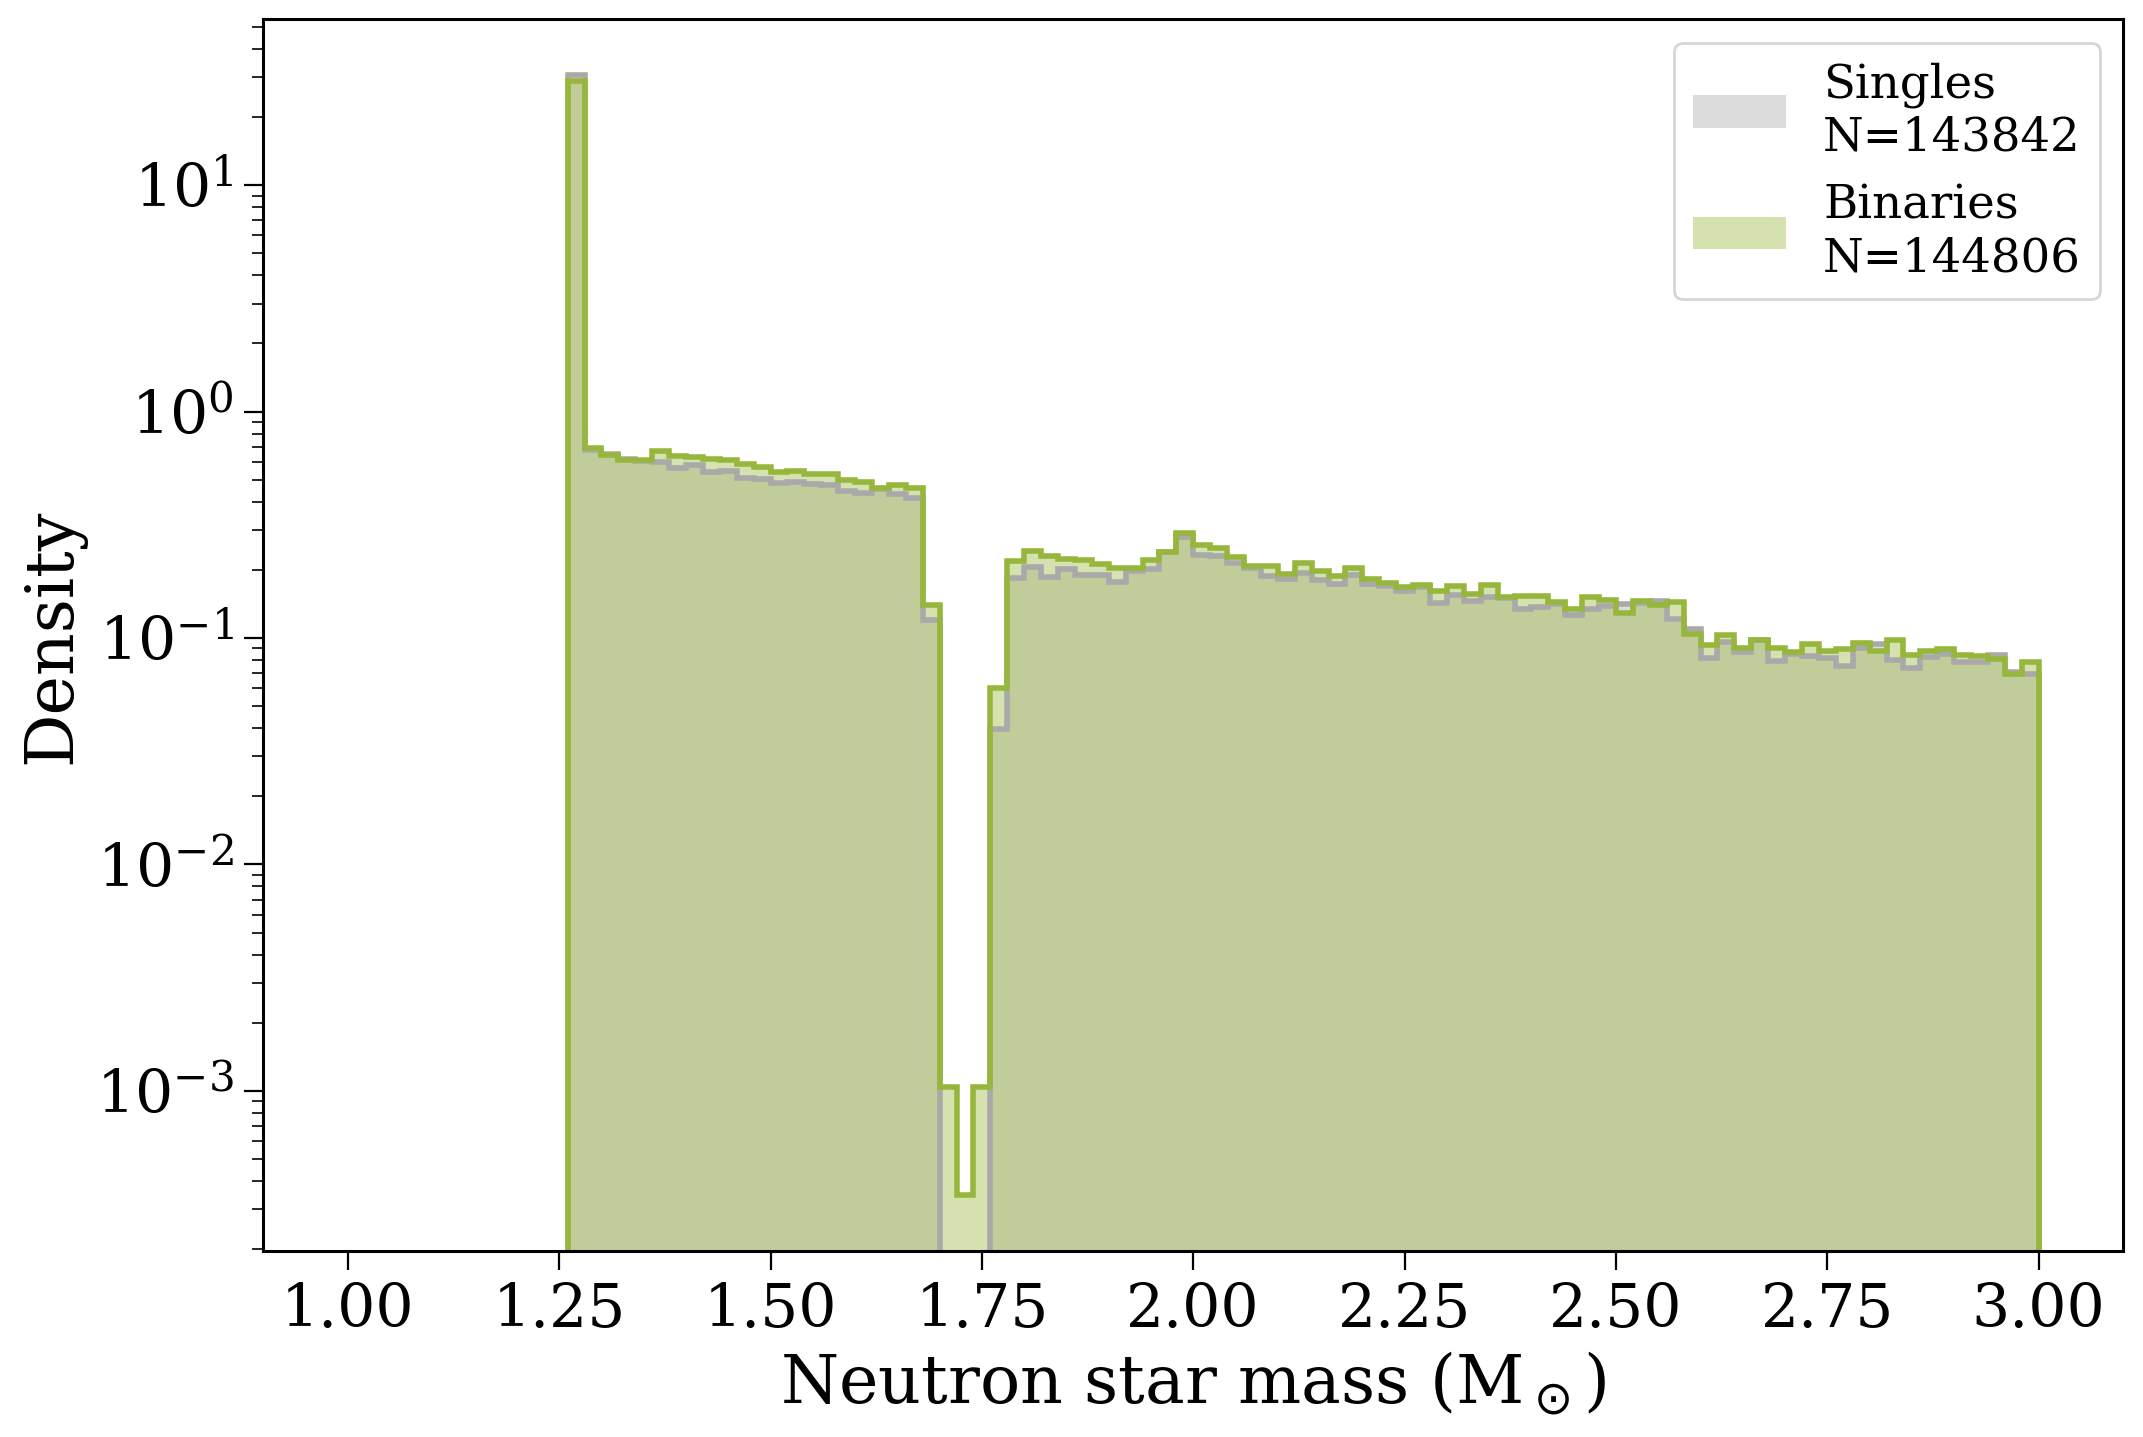

(<Figure size 1200x800 with 1 Axes>,
 <Axes: xlabel='Neutron star mass (M$_\\odot$)', ylabel='Density'>)

In [12]:
plotting.compare_table_quantity(
    pops=[singles, binaries],
    quantity="mass",
    kstar=14,
    bins=np.linspace(3, 50, 150),
    xlabel="Black Hole Mass (M$_\odot$)",
    ylabel="Density",
)

plotting.compare_table_quantity(
    pops=[singles, binaries],
    quantity="mass",
    kstar=13,
    bins=np.linspace(1, 3, 101),
    xlabel="Neutron star mass (M$_\odot$)",
    ylabel="Density",
    yscale="log"
)

# Kinematics

In [13]:
kinematics = helpers.get_kinematics([singles, binaries])

stars = cogsworth.sfh.SandersBinney2015(
    size=200000,
    **{
        "potential": binaries.galactic_potential,
        "time_bins": 5,
        "verbose": True
    }
)

Pre-computing lookback time, guiding radius and frequency interpolations
Initiating sampling procedure
  Sampling 162110 stars from the thin_disc
    Sampling 19215 stars with lookback times between 0.00 Gyr and 2.00 Gyr
    Sampling 25037 stars with lookback times between 2.00 Gyr and 4.00 Gyr
    Sampling 31370 stars with lookback times between 4.00 Gyr and 6.00 Gyr
    Sampling 38988 stars with lookback times between 6.00 Gyr and 8.00 Gyr
    Sampling 47500 stars with lookback times between 8.00 Gyr and 10.00 Gyr
  Sampling 37890 stars from the thick_disc
    Sampling 37890 stars with lookback times between 10.00 Gyr and 12.00 Gyr


## Scale heights

How does one calculate scale height? There's two ways I could see:

- The height at which the maximum decreases by a factor of $e$
- The height where the cumulative distribution reaches 0.5

In [14]:
from scipy.optimize import curve_fit
def exponential(x, a, b):
    return a * np.exp(-b * x)

def estimate_scale_height(z, bins=np.linspace(0, 2, 101),
                          plot=False, fig=None, ax=None, show=True,
                          label="", colour="black",
                          **kwargs):
    """Estimate the scale height of a distribution given z-positions."""
    z = np.abs(z)
    
    # remove units for calculation if they exist
    if hasattr(z, 'unit'):
        z = z.to(u.kpc).value

    hist, bin_edges = np.histogram(z, bins=bins)
    bin_centres = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    scale_height = bin_centres[hist < hist.max() / np.e][0]

    smooth_hist = gaussian_filter(hist, sigma=2)

    p0 = [smooth_hist.max(), 1 / scale_height]
    popt, pcov = curve_fit(exponential, bin_centres, smooth_hist, p0=p0)
    scale_height = 1 / popt[1]

    if plot:

        if fig is None or ax is None:
            fig, ax = plt.subplots()

        ax.plot(bin_centres, hist, label=label, color=colour)
        ax.plot(bin_centres, exponential(bin_centres, *popt), color=colour, ls='--', alpha=0.5)

        ax.axvline(scale_height, color=colour, ls='dotted', alpha=0.5)
        ax.annotate(f"{scale_height * 1000:.0f} pc", xy=(scale_height, smooth_hist.max()), fontsize=0.6*fs,
                    rotation=90, color=colour, ha='center', va='top', bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=colour))
        
        ax.set(
            xlabel="|z| (kpc)",
            ylabel="Count",
        )
        ax.legend(fontsize=0.7*fs)

        if show:
            plt.show()

        return scale_height, fig, ax
    else:
        return scale_height, None, None

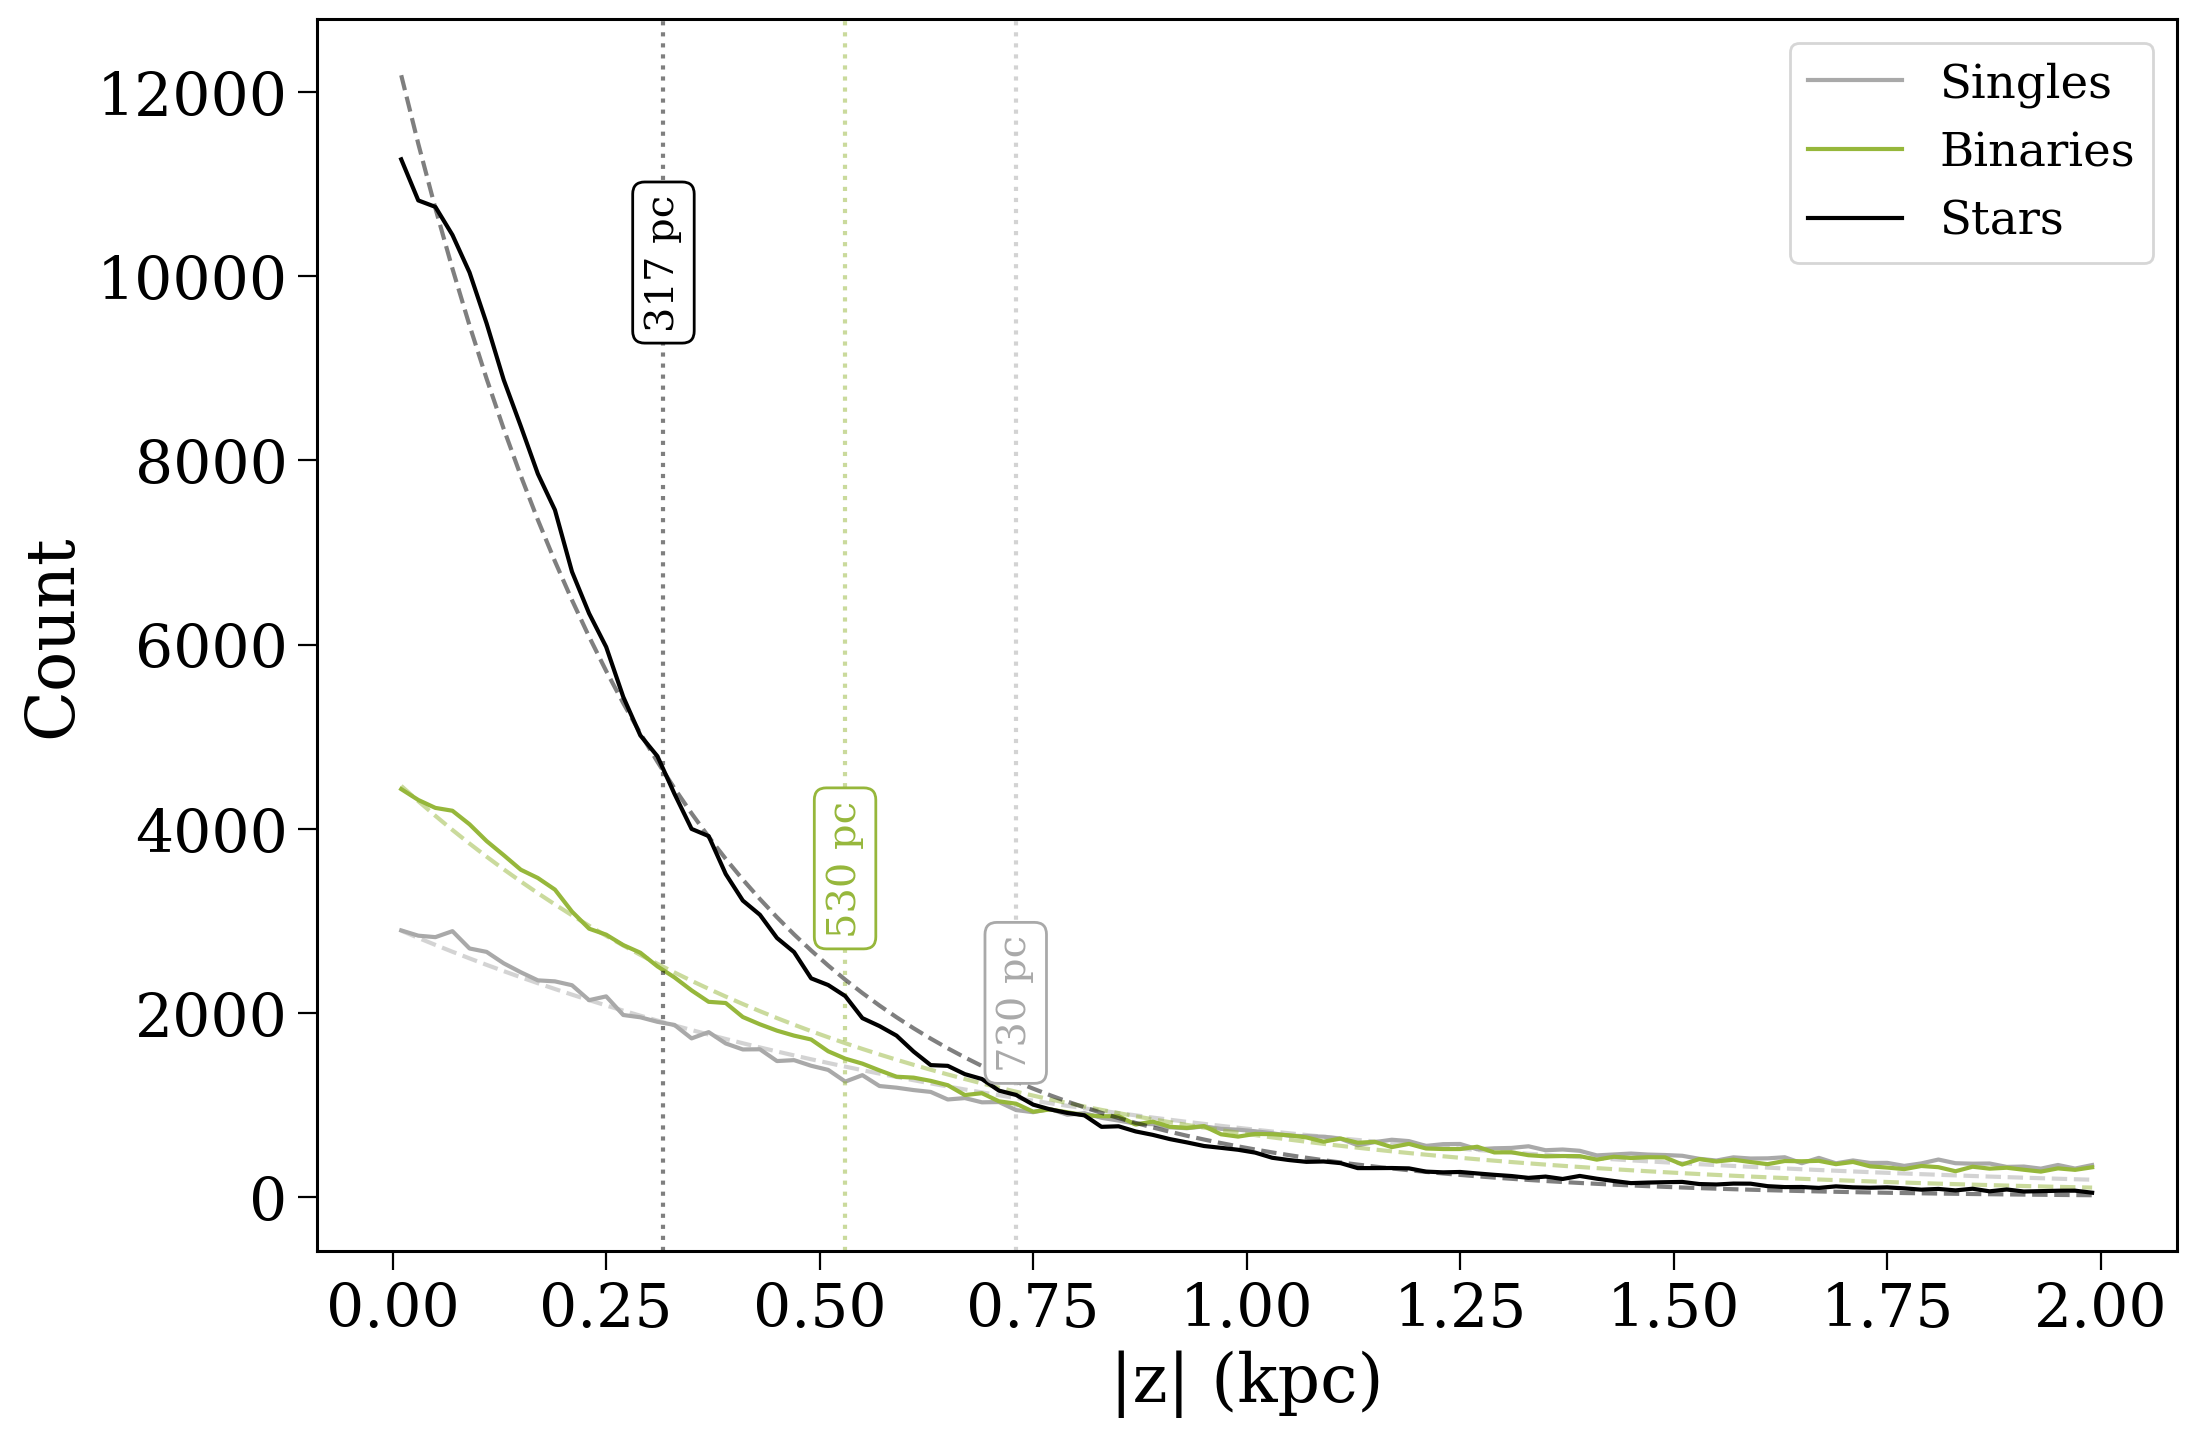

In [15]:
fig, ax = plt.subplots()

for z, label, colour in zip(
    [kinematics["Singles"]["pos"]["CO"][:, 2], kinematics["Binaries"]["pos"]["CO"][:, 2], stars.z],
    ["Singles", "Binaries", "Stars"],
    [singles.colour, binaries.colour, "black"]
):
    scale_height, _, _ = plotting.estimate_scale_height(
        z=z,
        plot=True,
        label=label,
        colour=colour,
        show=False,
        fig=fig,
        ax=ax
    )

plt.show()

## Vertical position histograms

Singles 0.3716892636187916
Binaries 0.46864322436275346
Singles 0.27499423357851305
Binaries 0.3694737368184317


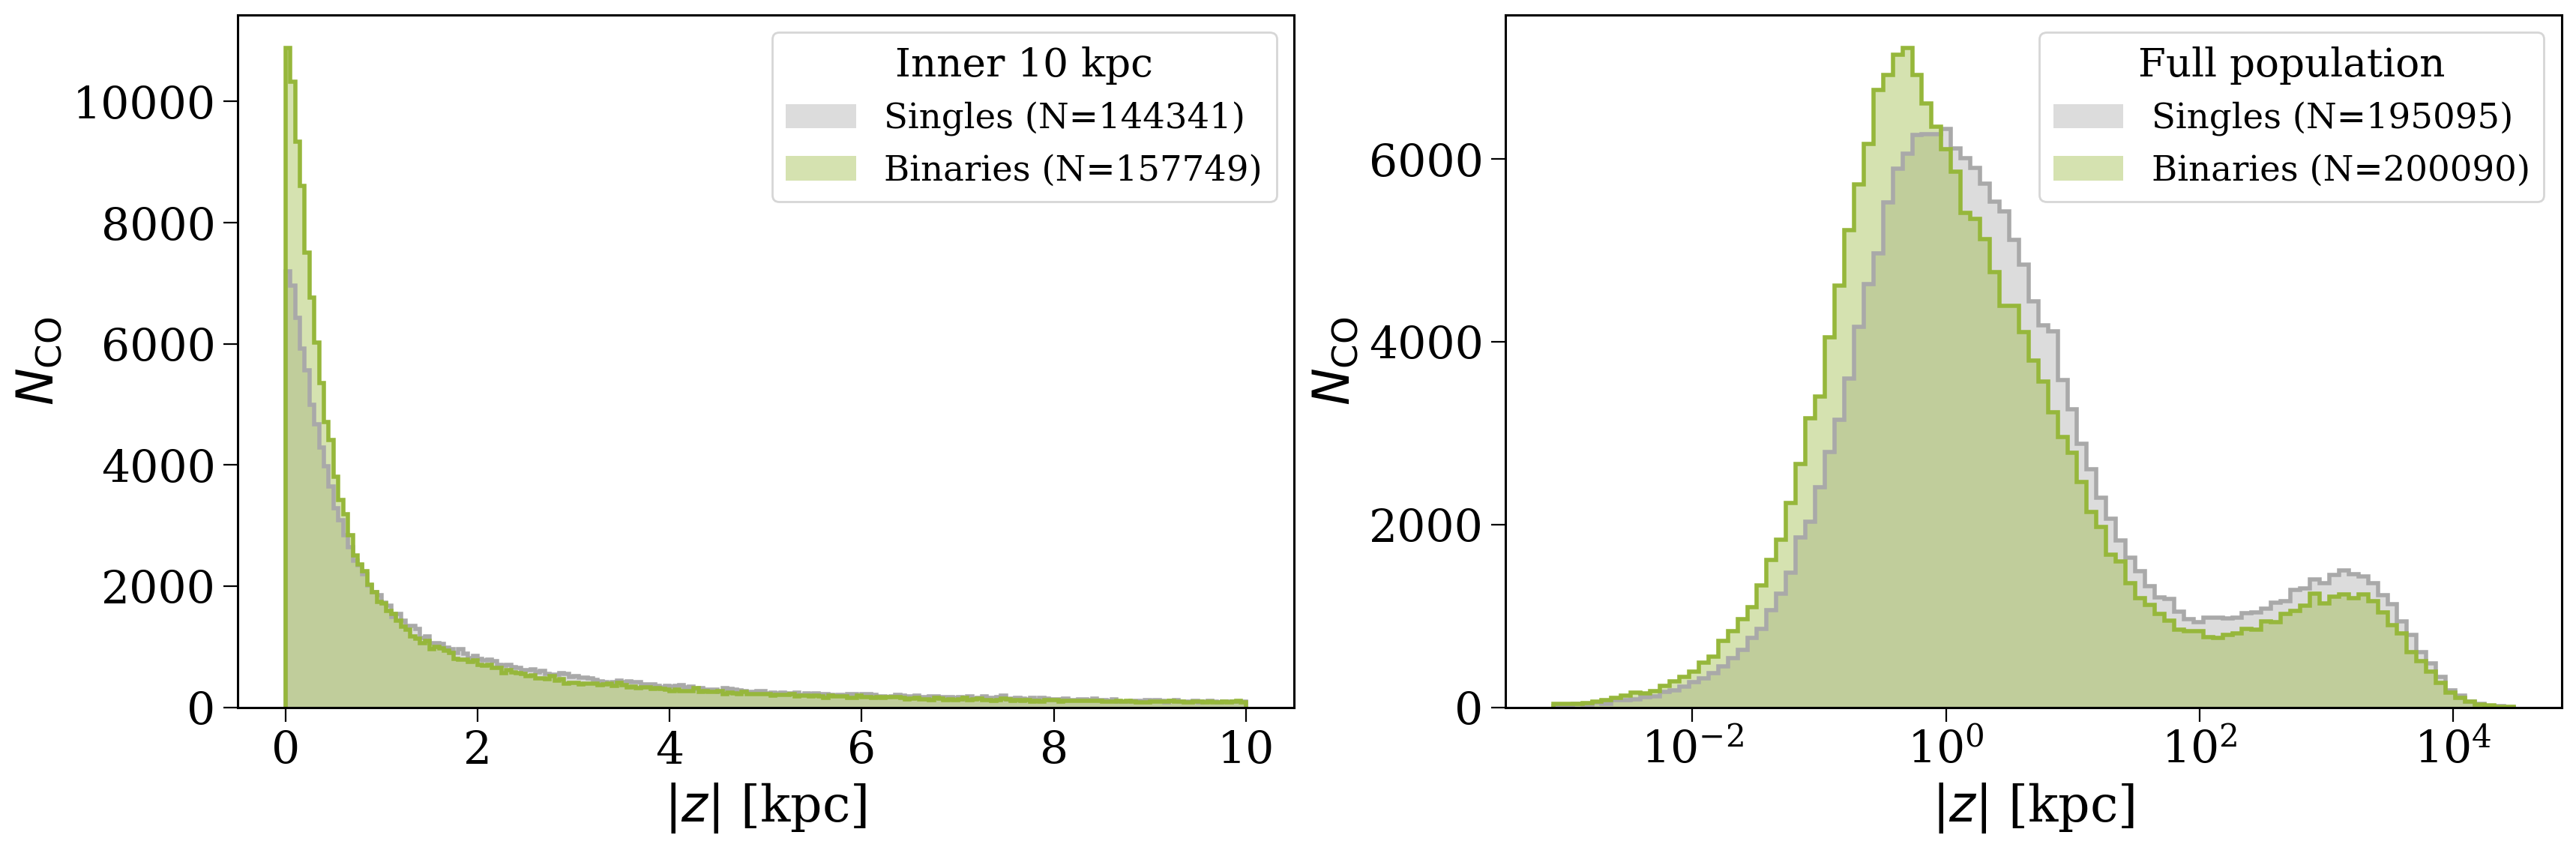

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

scales = ['linear', 'log']
bin_list = [np.linspace(0, 10, 201), np.geomspace(8e-4, 3e4, 100)]
labels = ['Inner 10 kpc', 'Full population']

for ax, scale, bins, label in zip(axes, scales, bin_list, labels):
    for pop in [singles, binaries]:
        co_pos = kinematics[pop.label]["pos"]["CO"]

        mask = np.abs(co_pos[:, 2].to(u.kpc).value) < bins[-1]

        print(pop.label, (abs(co_pos[:, 2].to(u.kpc).value) < 0.5).sum() / mask.sum())

        ax.hist(np.abs(co_pos[:, 2].to(u.kpc).value), bins=bins, histtype='step', lw=2, color=pop.colour)
        ax.hist(np.abs(co_pos[:, 2].to(u.kpc).value), bins=bins, alpha=0.4, color=pop.colour,
                label=f'{pop.label} (N={len(co_pos[mask])})')

    ax.set(
        xscale=scale,
        xlabel=r'$|z|$ [kpc]',
        ylabel=r'$N_{\rm CO}$',
    )
    ax.legend(title=label)
plt.show()

Singles 0.00827459393196445
Binaries 0.007552958080111838
Singles 0.0059508554675086365
Binaries 0.005832404579961917


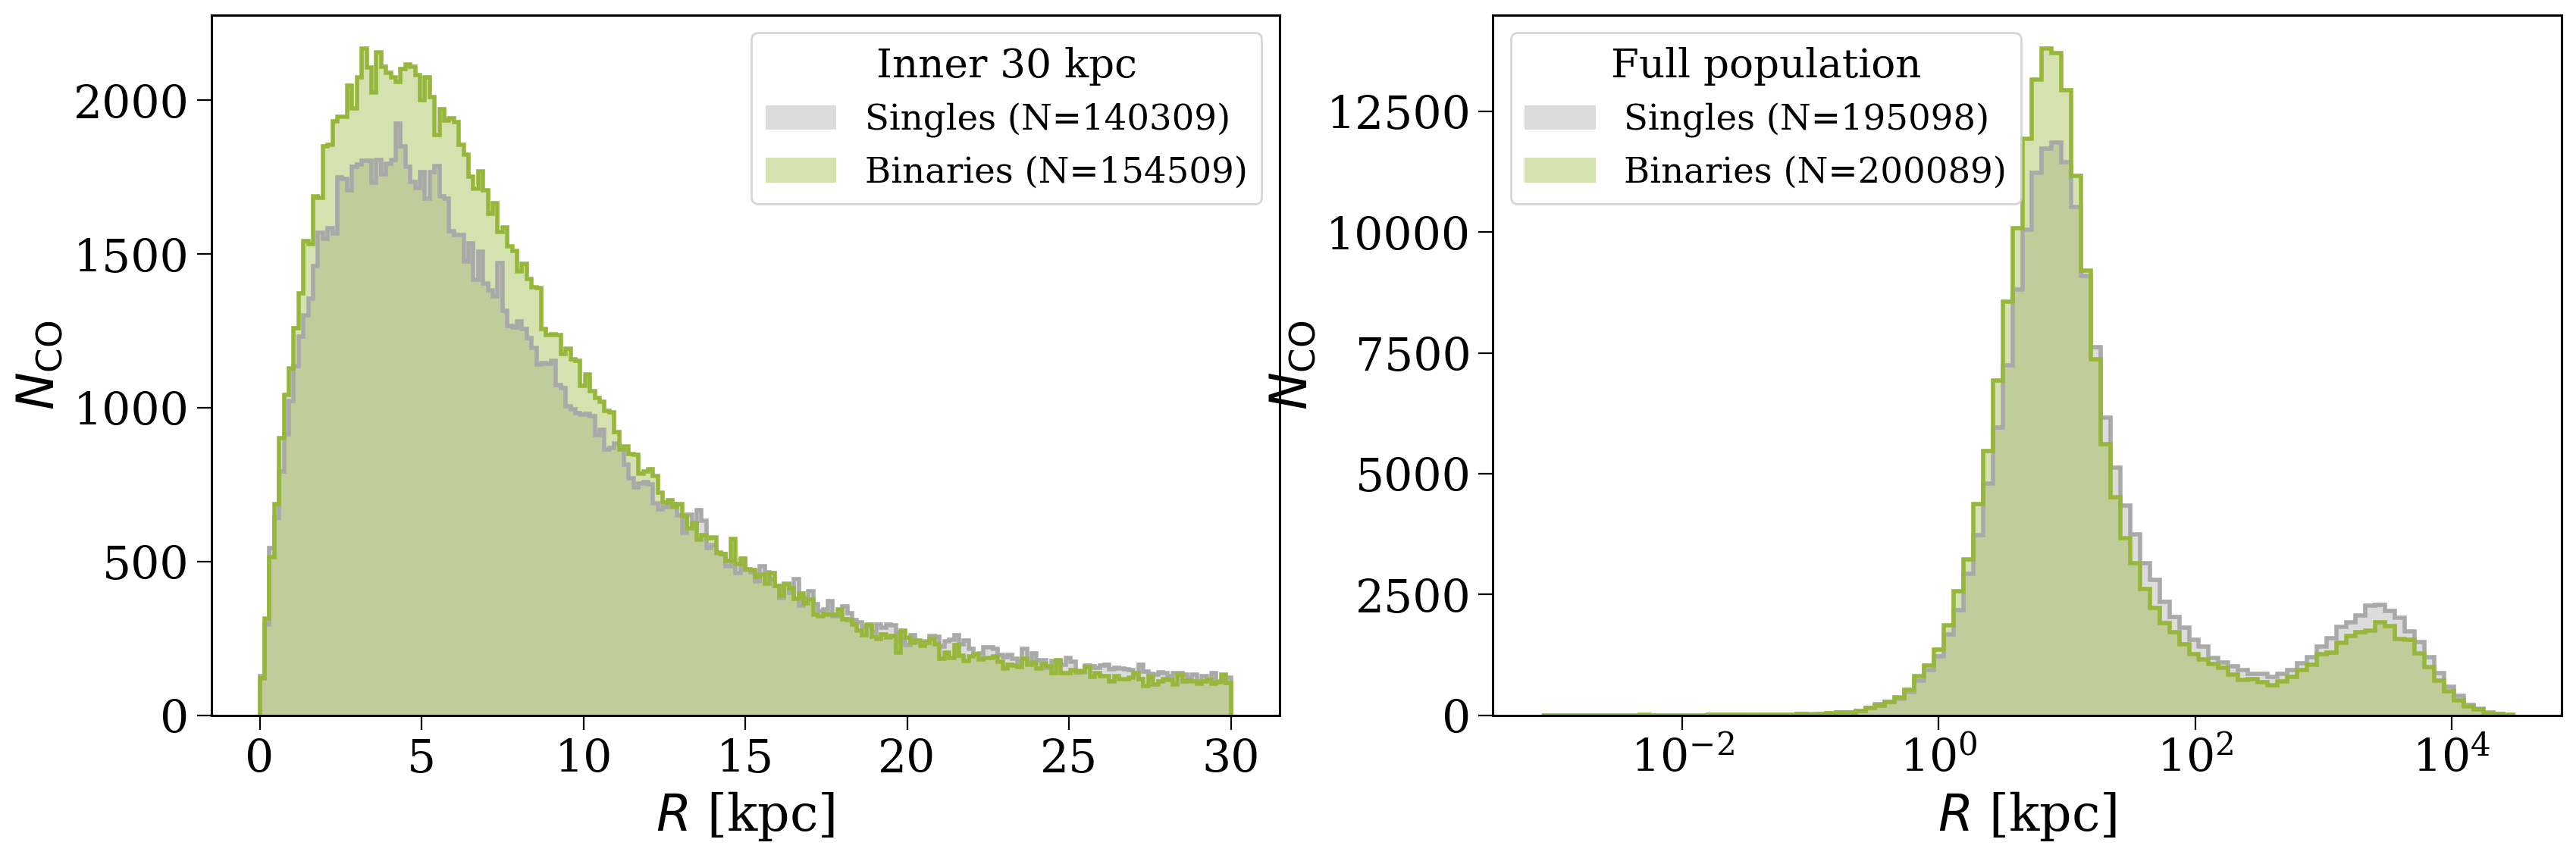

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

scales = ['linear', 'log']
bin_list = [np.linspace(0, 30, 201), np.geomspace(8e-4, 3e4, 100)]
labels = ['Inner 30 kpc', 'Full population']

for ax, scale, bins, label in zip(axes, scales, bin_list, labels):
    for pop in [singles, binaries]:
        co_pos = kinematics[pop.label]["pos"]["CO"]
        r = np.sqrt(co_pos[:, 0]**2 + co_pos[:, 1]**2).to(u.kpc).value

        mask = r < bins[-1]

        print(pop.label, (r < 0.5).sum() / mask.sum())

        ax.hist(r, bins=bins, histtype='step', lw=2, color=pop.colour)
        ax.hist(r, bins=bins, alpha=0.4, color=pop.colour,
                label=f'{pop.label} (N={len(co_pos[mask])})')

    ax.set(
        xscale=scale,
        xlabel=r'$R$ [kpc]',
        ylabel=r'$N_{\rm CO}$',
    )
    ax.legend(title=label)
plt.show()

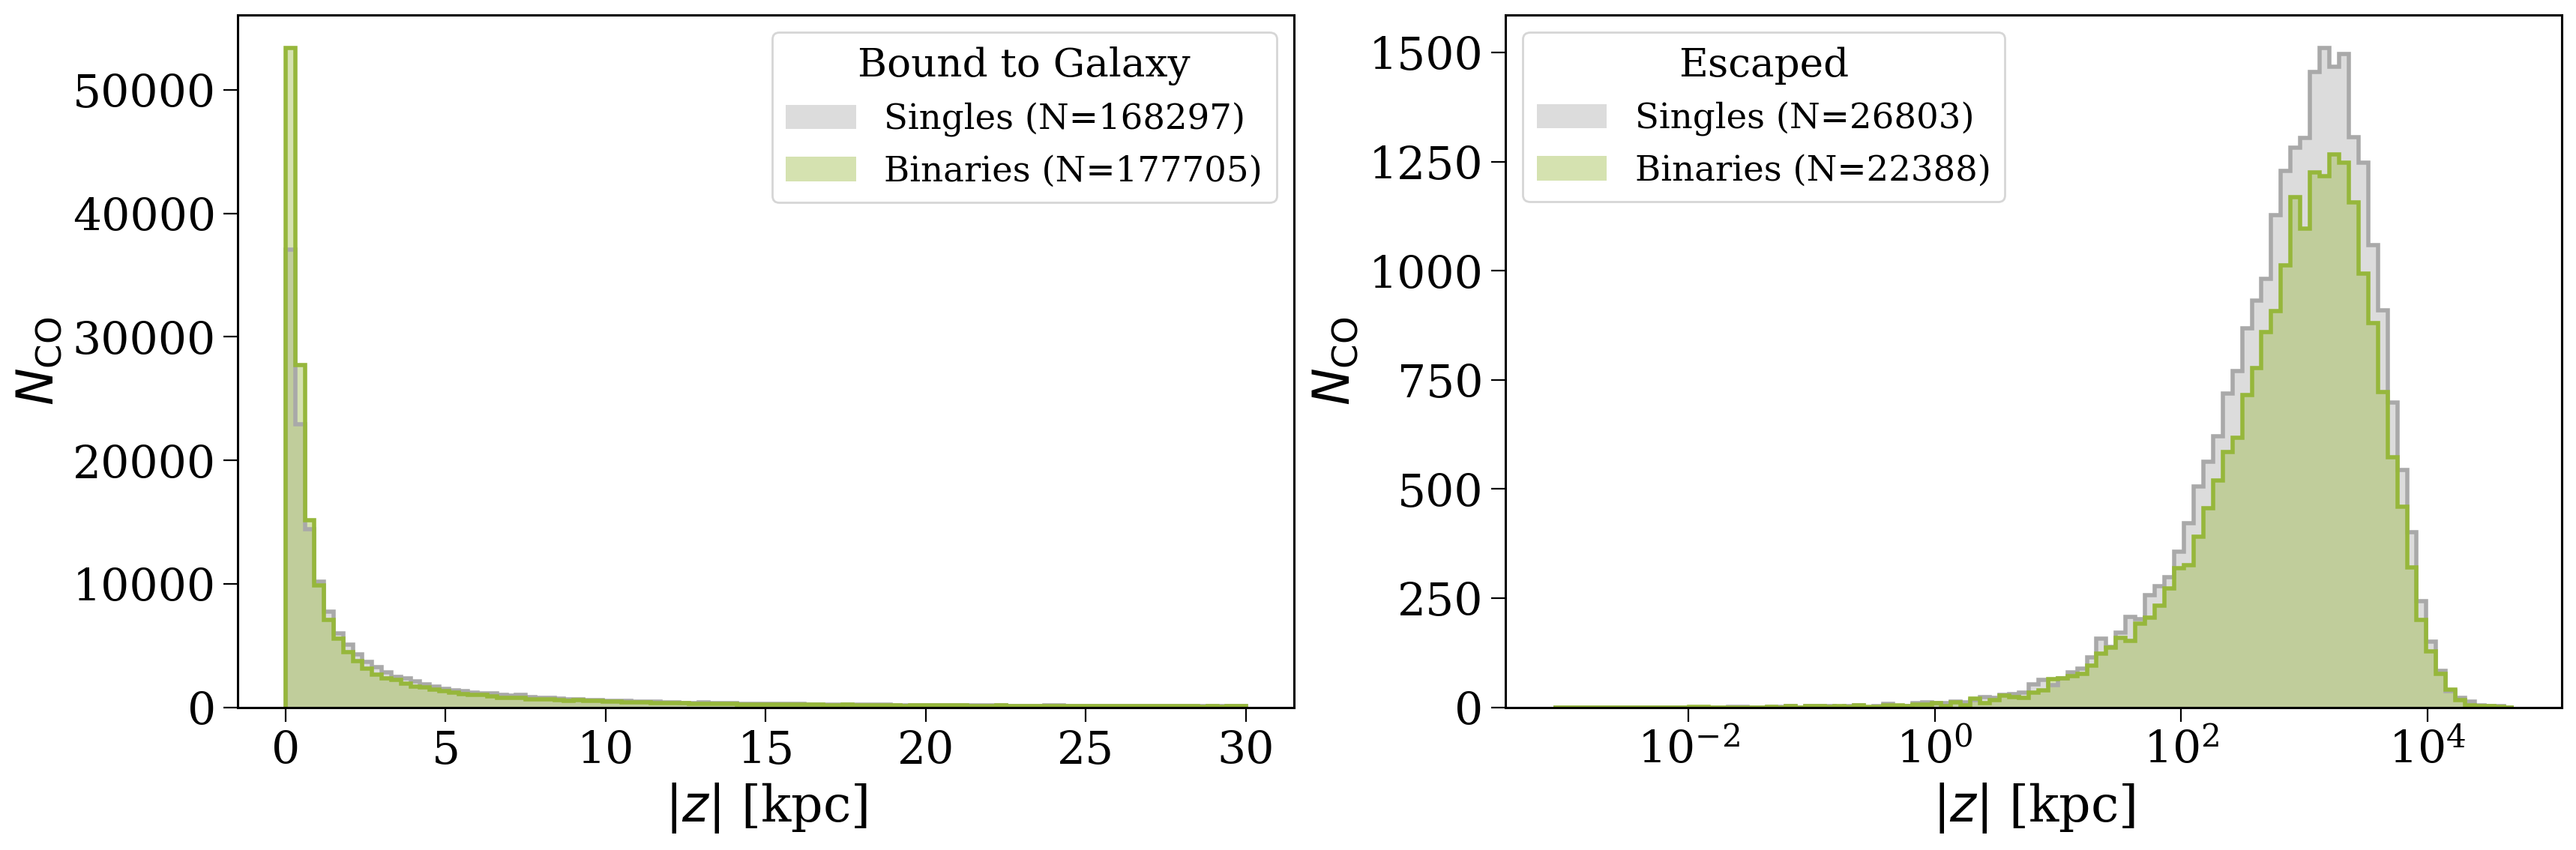

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

scales = ['linear', 'log']
bin_list = [np.linspace(0, 30, 101), np.geomspace(8e-4, 5e4, 100)]
labels = ['Bound to Galaxy', "Escaped"]

for ax, scale, bins, label in zip(axes, scales, bin_list, labels):
    for pop in [singles, binaries]:
        co_pos = kinematics[pop.label]["pos"]["CO"]
        co_vel = kinematics[pop.label]["vel"]["CO"]

        co_V = np.linalg.norm(co_vel.to(u.km/u.s).value, axis=1)

        mask = co_V >= np.sqrt(-2 * pop.galactic_potential(co_pos.T)).to(u.km / u.s).value
        mask = mask if label == "Escaped" else ~mask

        ax.hist(np.abs(co_pos[:, 2].to(u.kpc).value)[mask], bins=bins, histtype='step', lw=2, color=pop.colour)
        ax.hist(np.abs(co_pos[:, 2].to(u.kpc).value)[mask], bins=bins, alpha=0.4, color=pop.colour,
                label=f'{pop.label} (N={len(co_pos[mask])})')

    ax.set(
        xscale=scale,
        xlabel=r'$|z|$ [kpc]',
        ylabel=r'$N_{\rm CO}$',
    )
    ax.legend(title=label)
plt.show()

## Density distributions

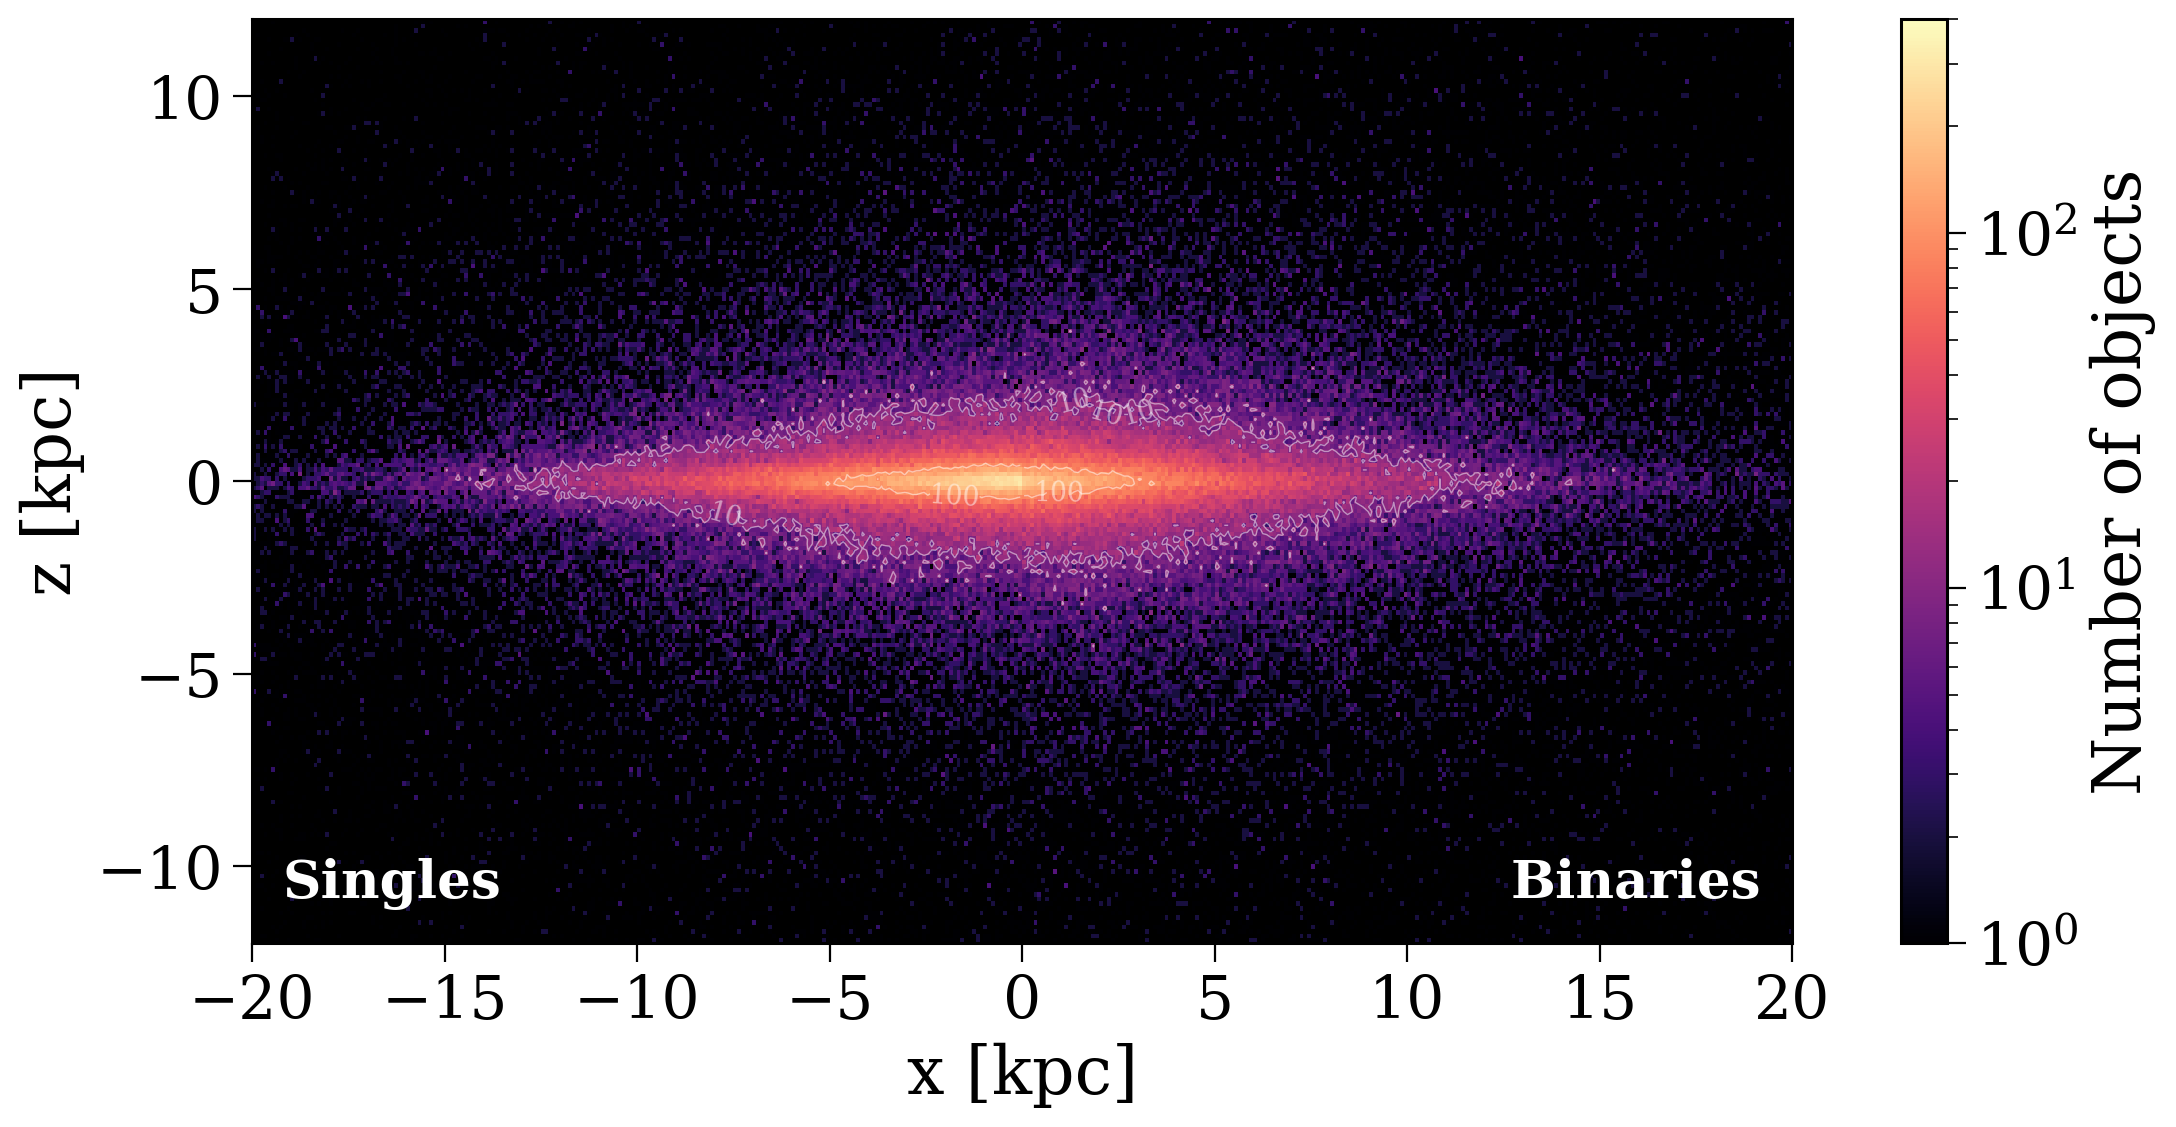

(<Figure size 1400x600 with 2 Axes>,
 <Axes: xlabel='x [kpc]', ylabel='z [kpc]'>)

In [29]:
reload(plotting)
plotting.plot_side_on_density(
    xs=[kinematics["Singles"]["pos"]["CO"][:, 0], kinematics["Binaries"]["pos"]["CO"][:, 0]],
    zs=[kinematics["Singles"]["pos"]["CO"][:, 2], kinematics["Binaries"]["pos"]["CO"][:, 2]],
    labels=["Singles", "Binaries"],
    xlim=20,
    zlim=12,
    n_bins=200,
    sigma=1.0,
    contours=[10, 100],
    apply_smoothing=False,
)

## Velocities

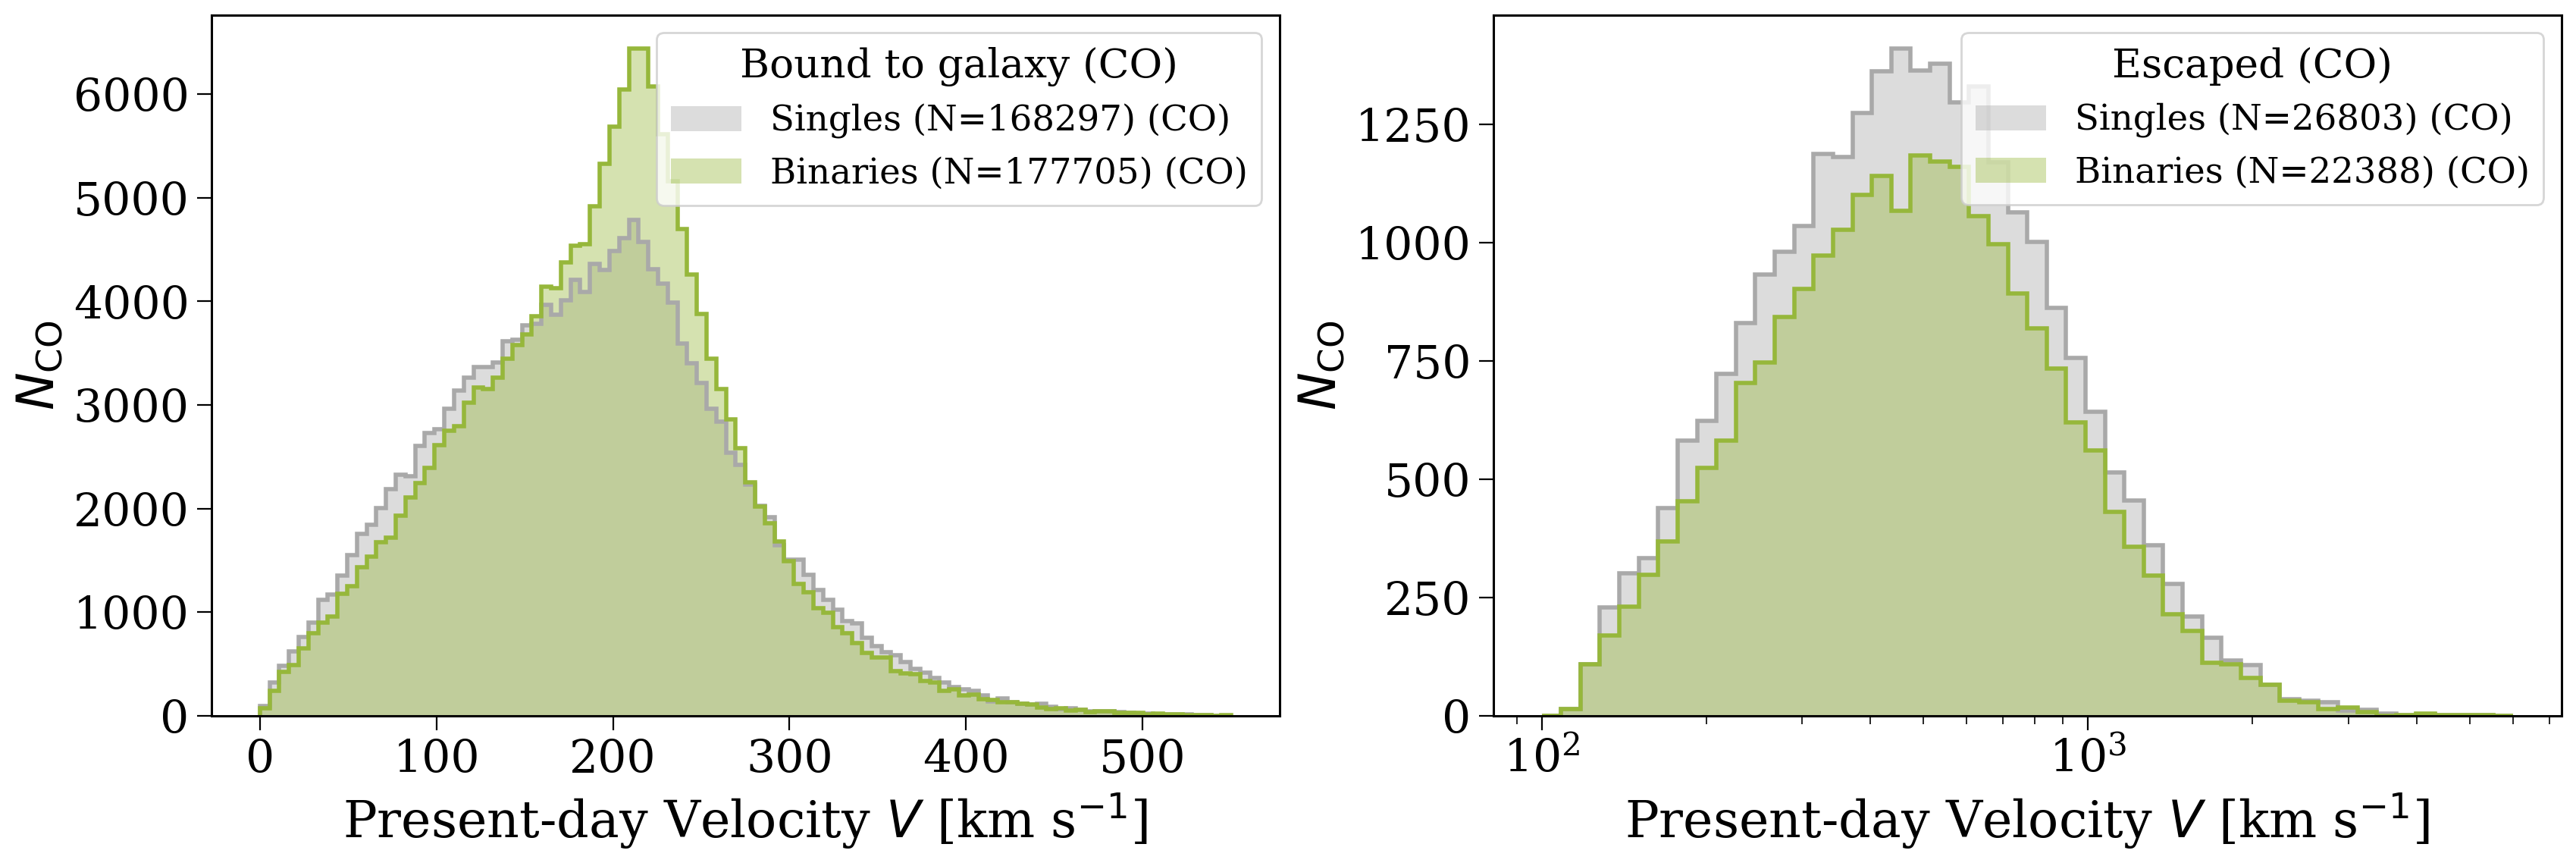

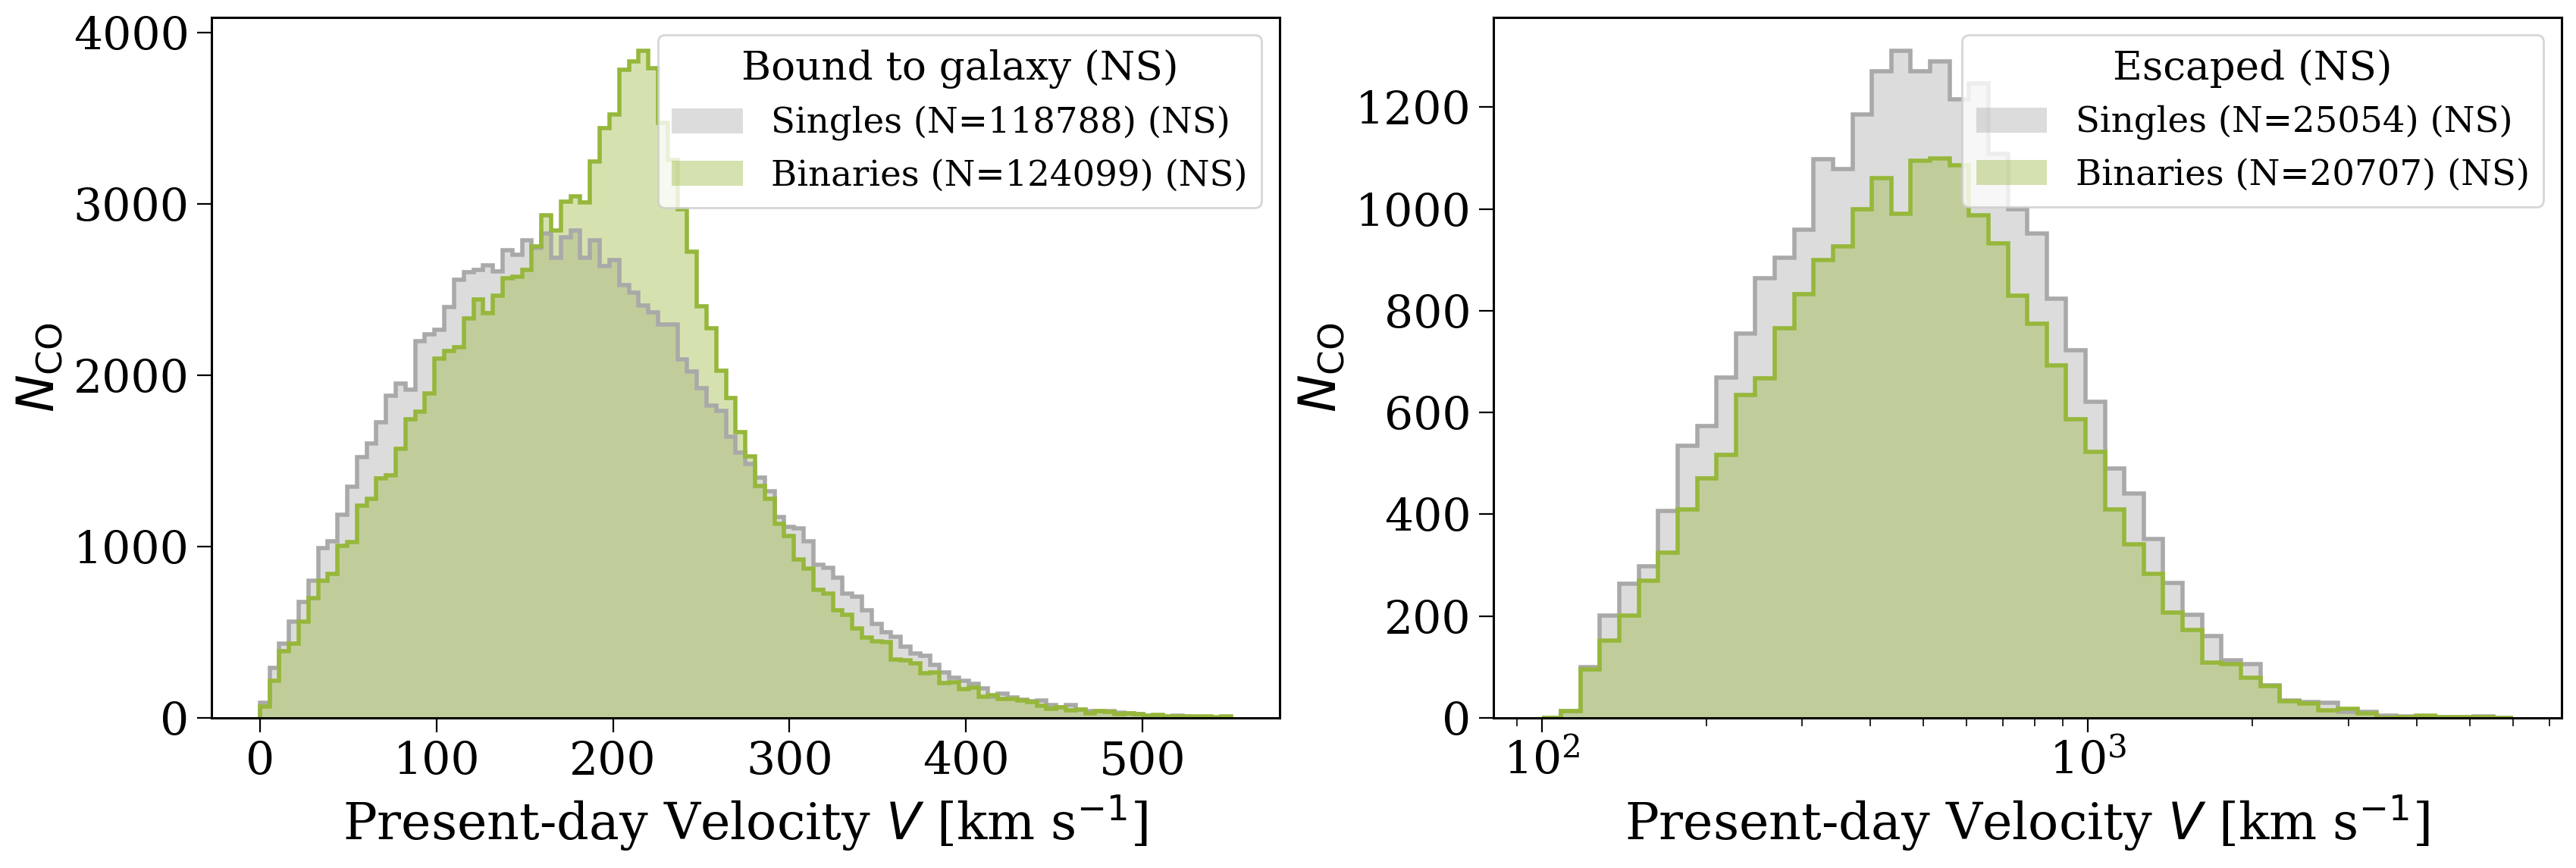

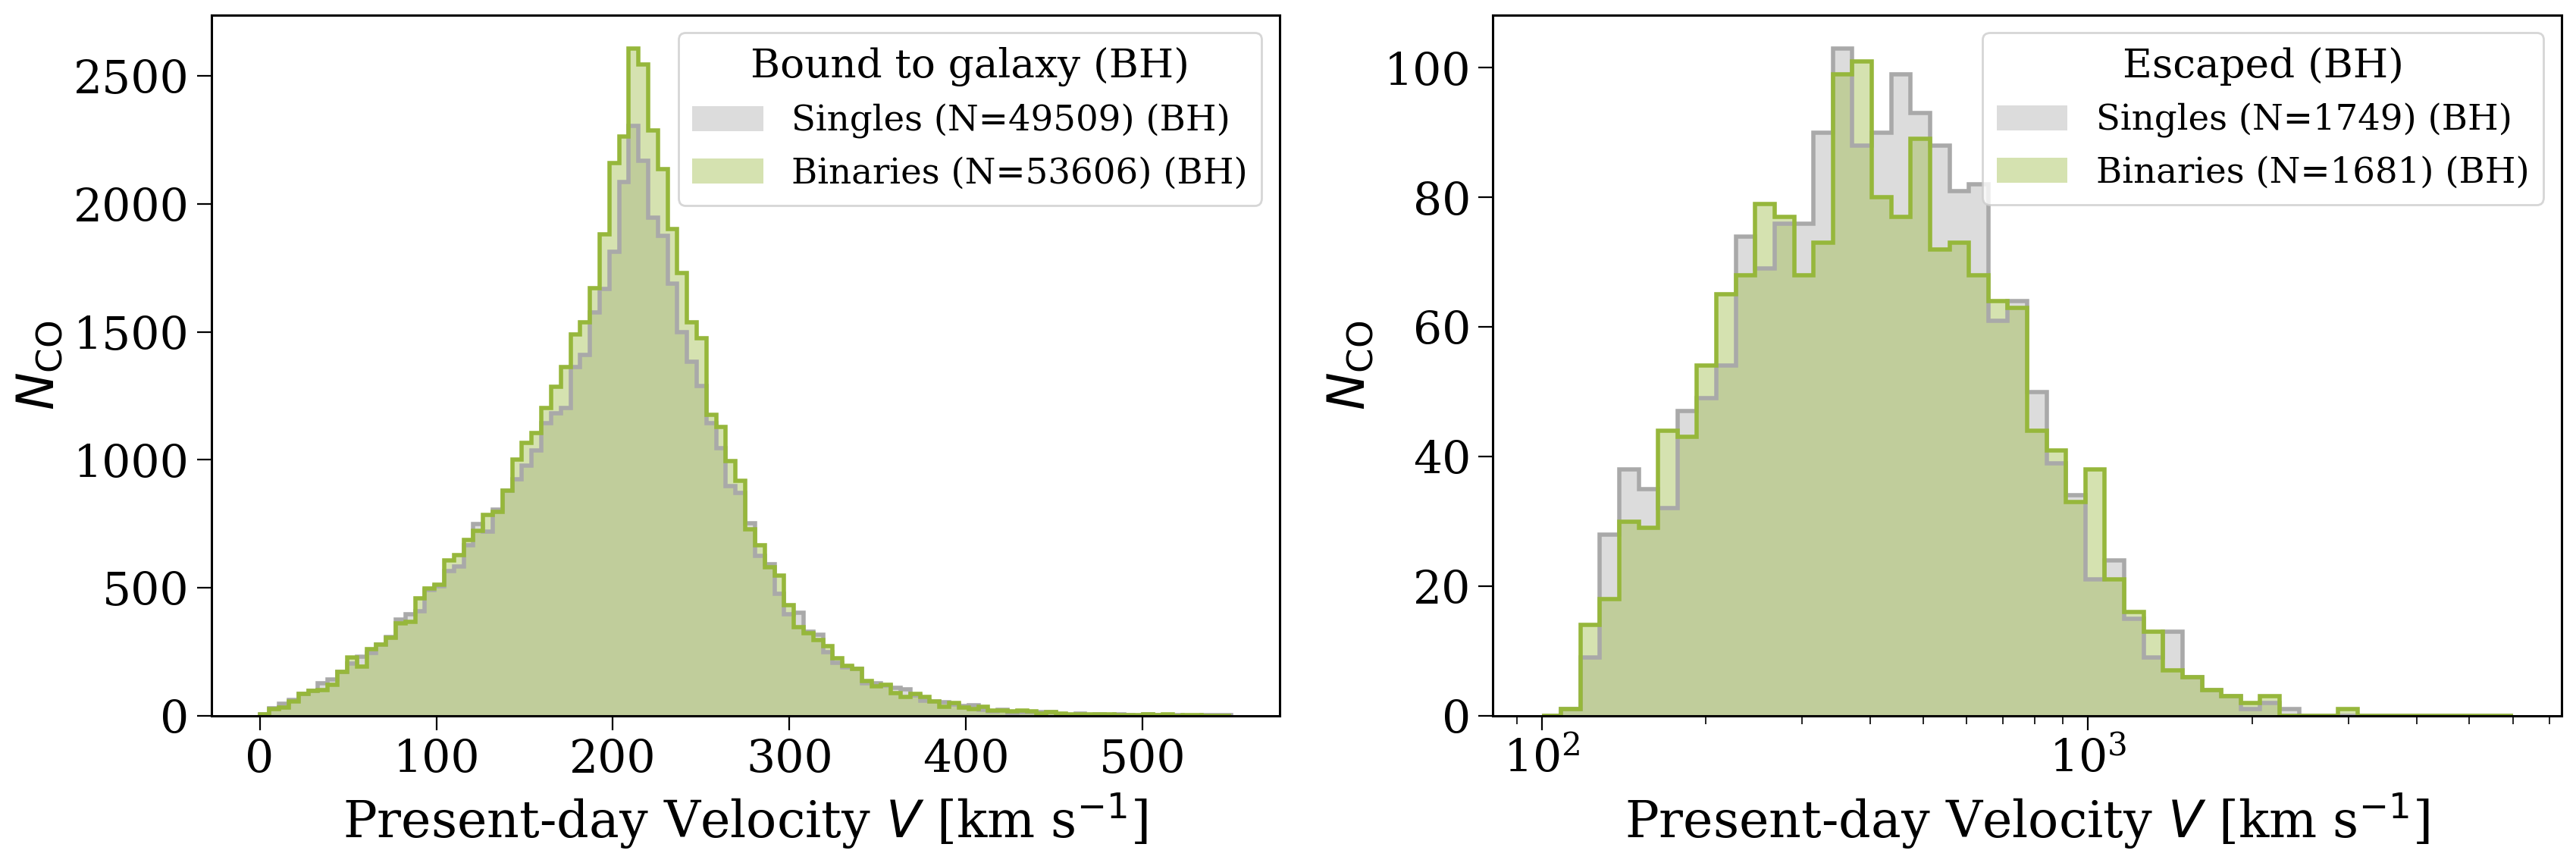

In [31]:
for co_type in ["CO", "NS", "BH"]:

    fig, axes = plt.subplots(1, 2, figsize=(20, 6))

    density = False

    for ax, label, bins, scale in zip(axes, ['Bound to galaxy', "Escaped"],
                                    [np.linspace(0, 550, 101), np.geomspace(1e2, 6e3, 51)], ['linear', 'log']):
        for pop in [singles, binaries]:
            co_pos = kinematics[pop.label]["pos"][co_type]
            co_vel = kinematics[pop.label]["vel"][co_type]

            co_V = np.linalg.norm(co_vel.to(u.km/u.s).value, axis=1)

            mask = co_V >= np.sqrt(-2 * pop.galactic_potential(co_pos.T)).to(u.km / u.s).value
            mask = mask if label == "Escaped" else ~mask
            co_V = co_V[mask]

            plotting.nice_transparent_hist(
                ax=ax,
                data=co_V,
                bins=bins,
                label=f'{pop.label} (N={len(co_V)})' + (f" ({co_type})" if co_type != "ALL" else ""),
                colour=pop.colour,
                density=density,
            )

            ax.set(
                xlabel=r'Present-day Velocity $V$ [km s$^{-1}$]',
                ylabel=r'$N_{\rm CO}$',
                xscale=scale,
            )
            ax.legend(title=label + f" ({co_type})" if co_type != "ALL" else label)
    plt.show()

## Kicks

195100
200182


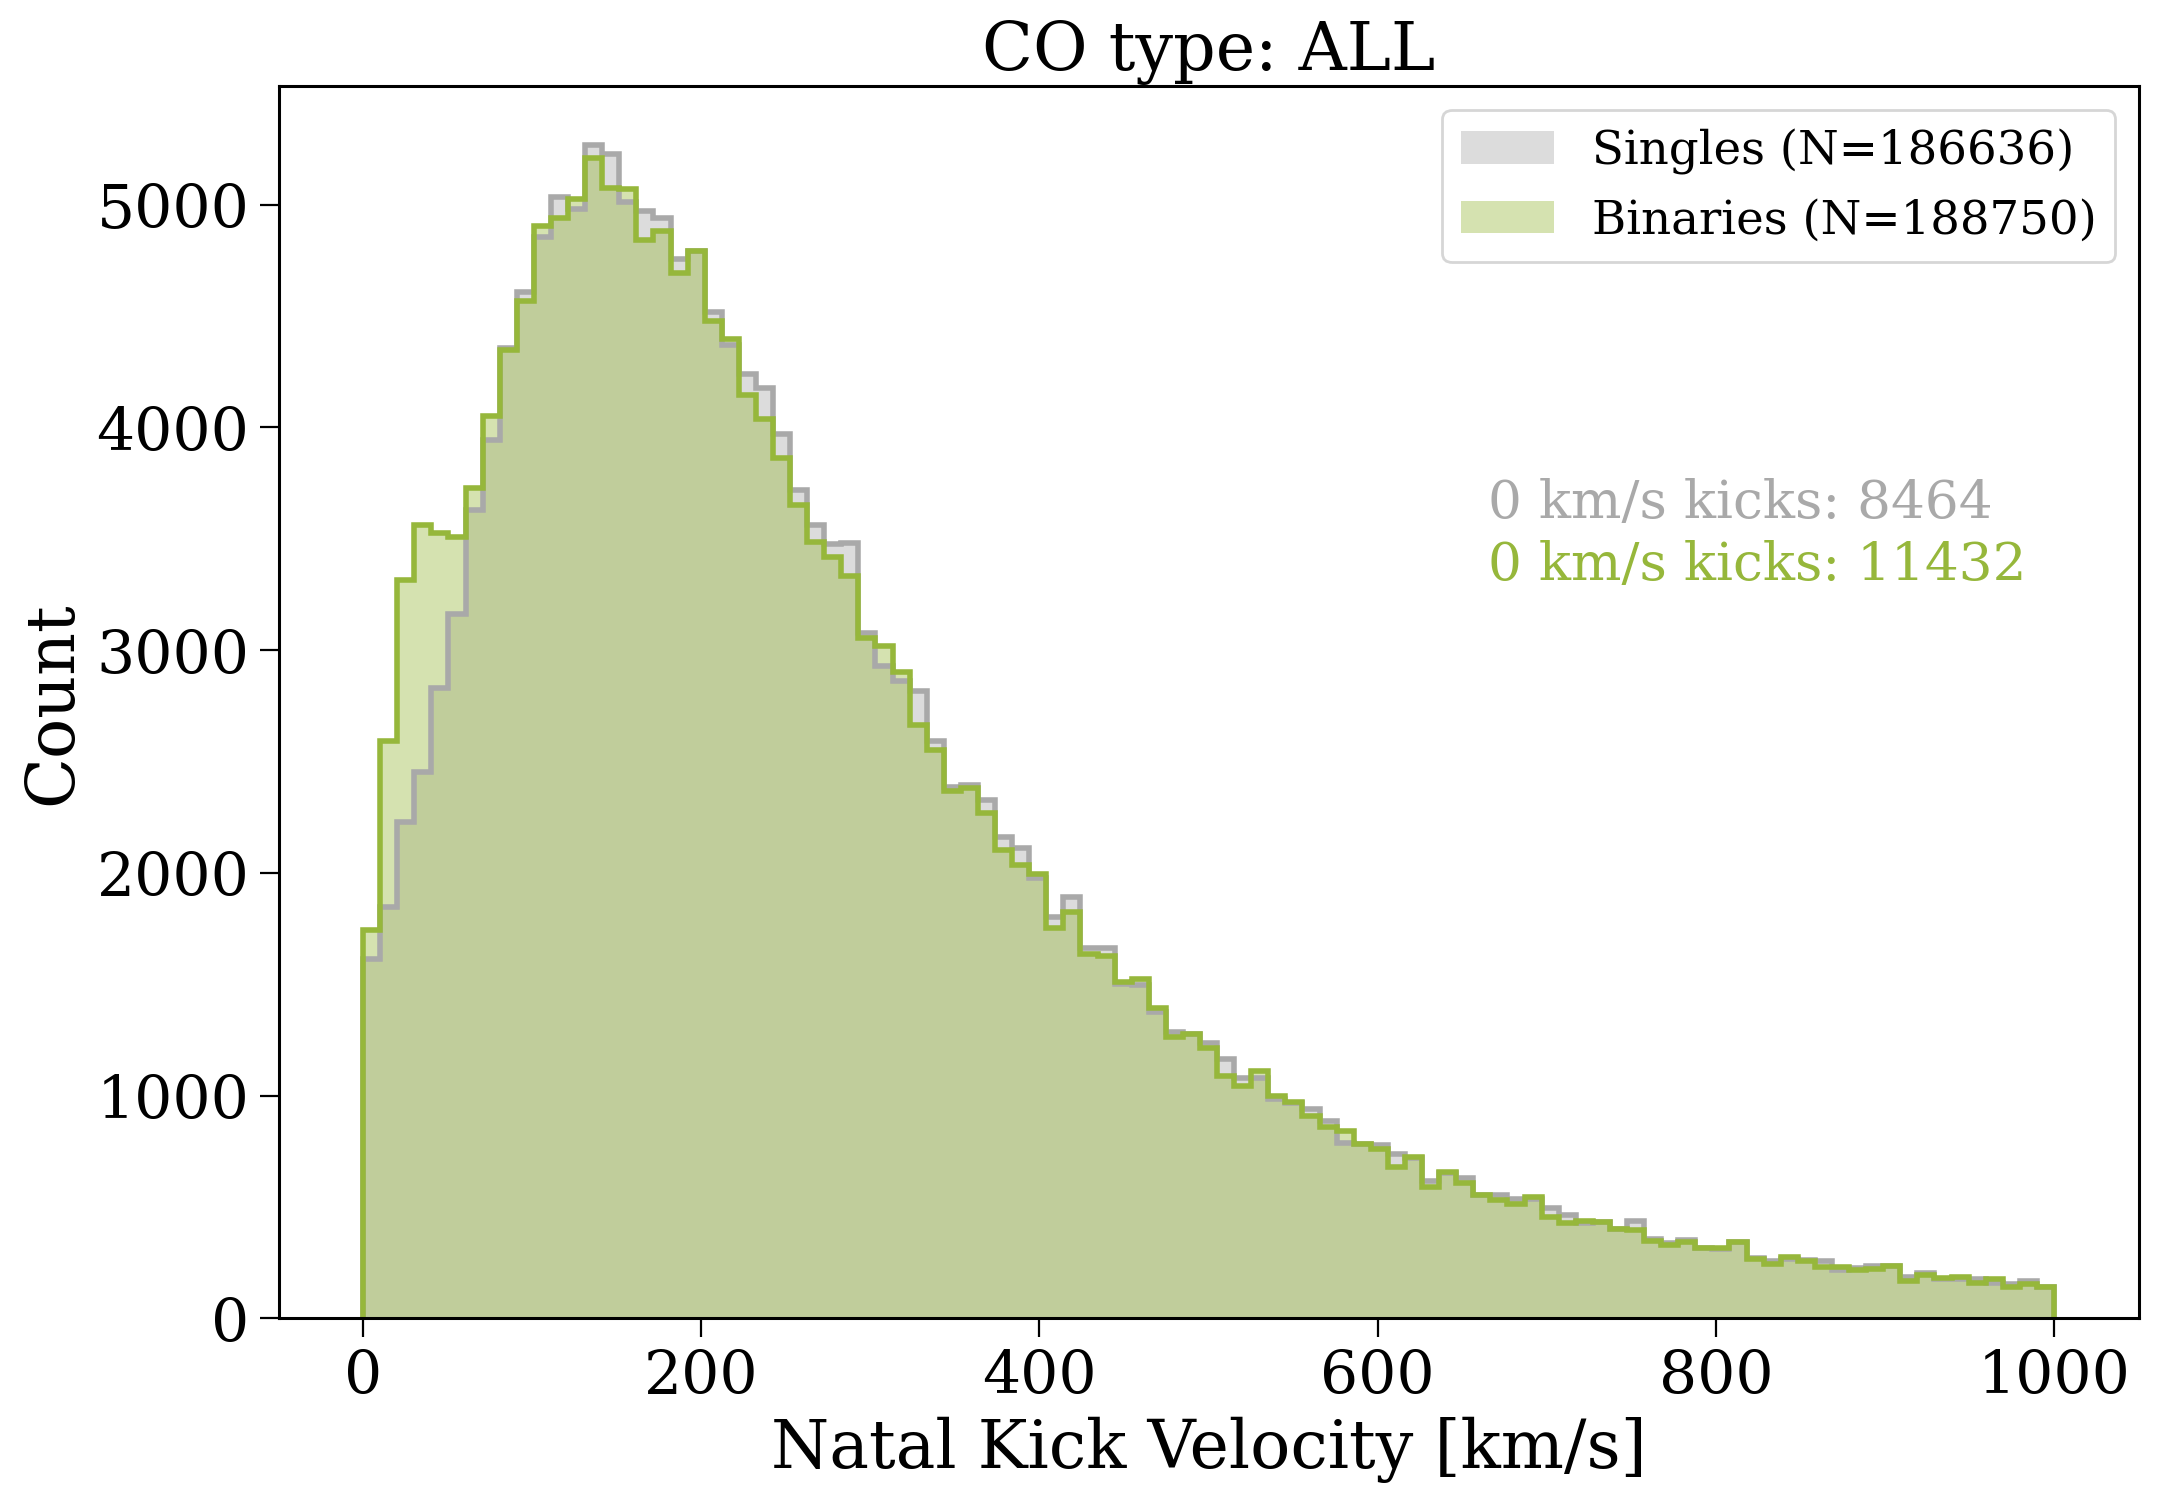

195100
200182


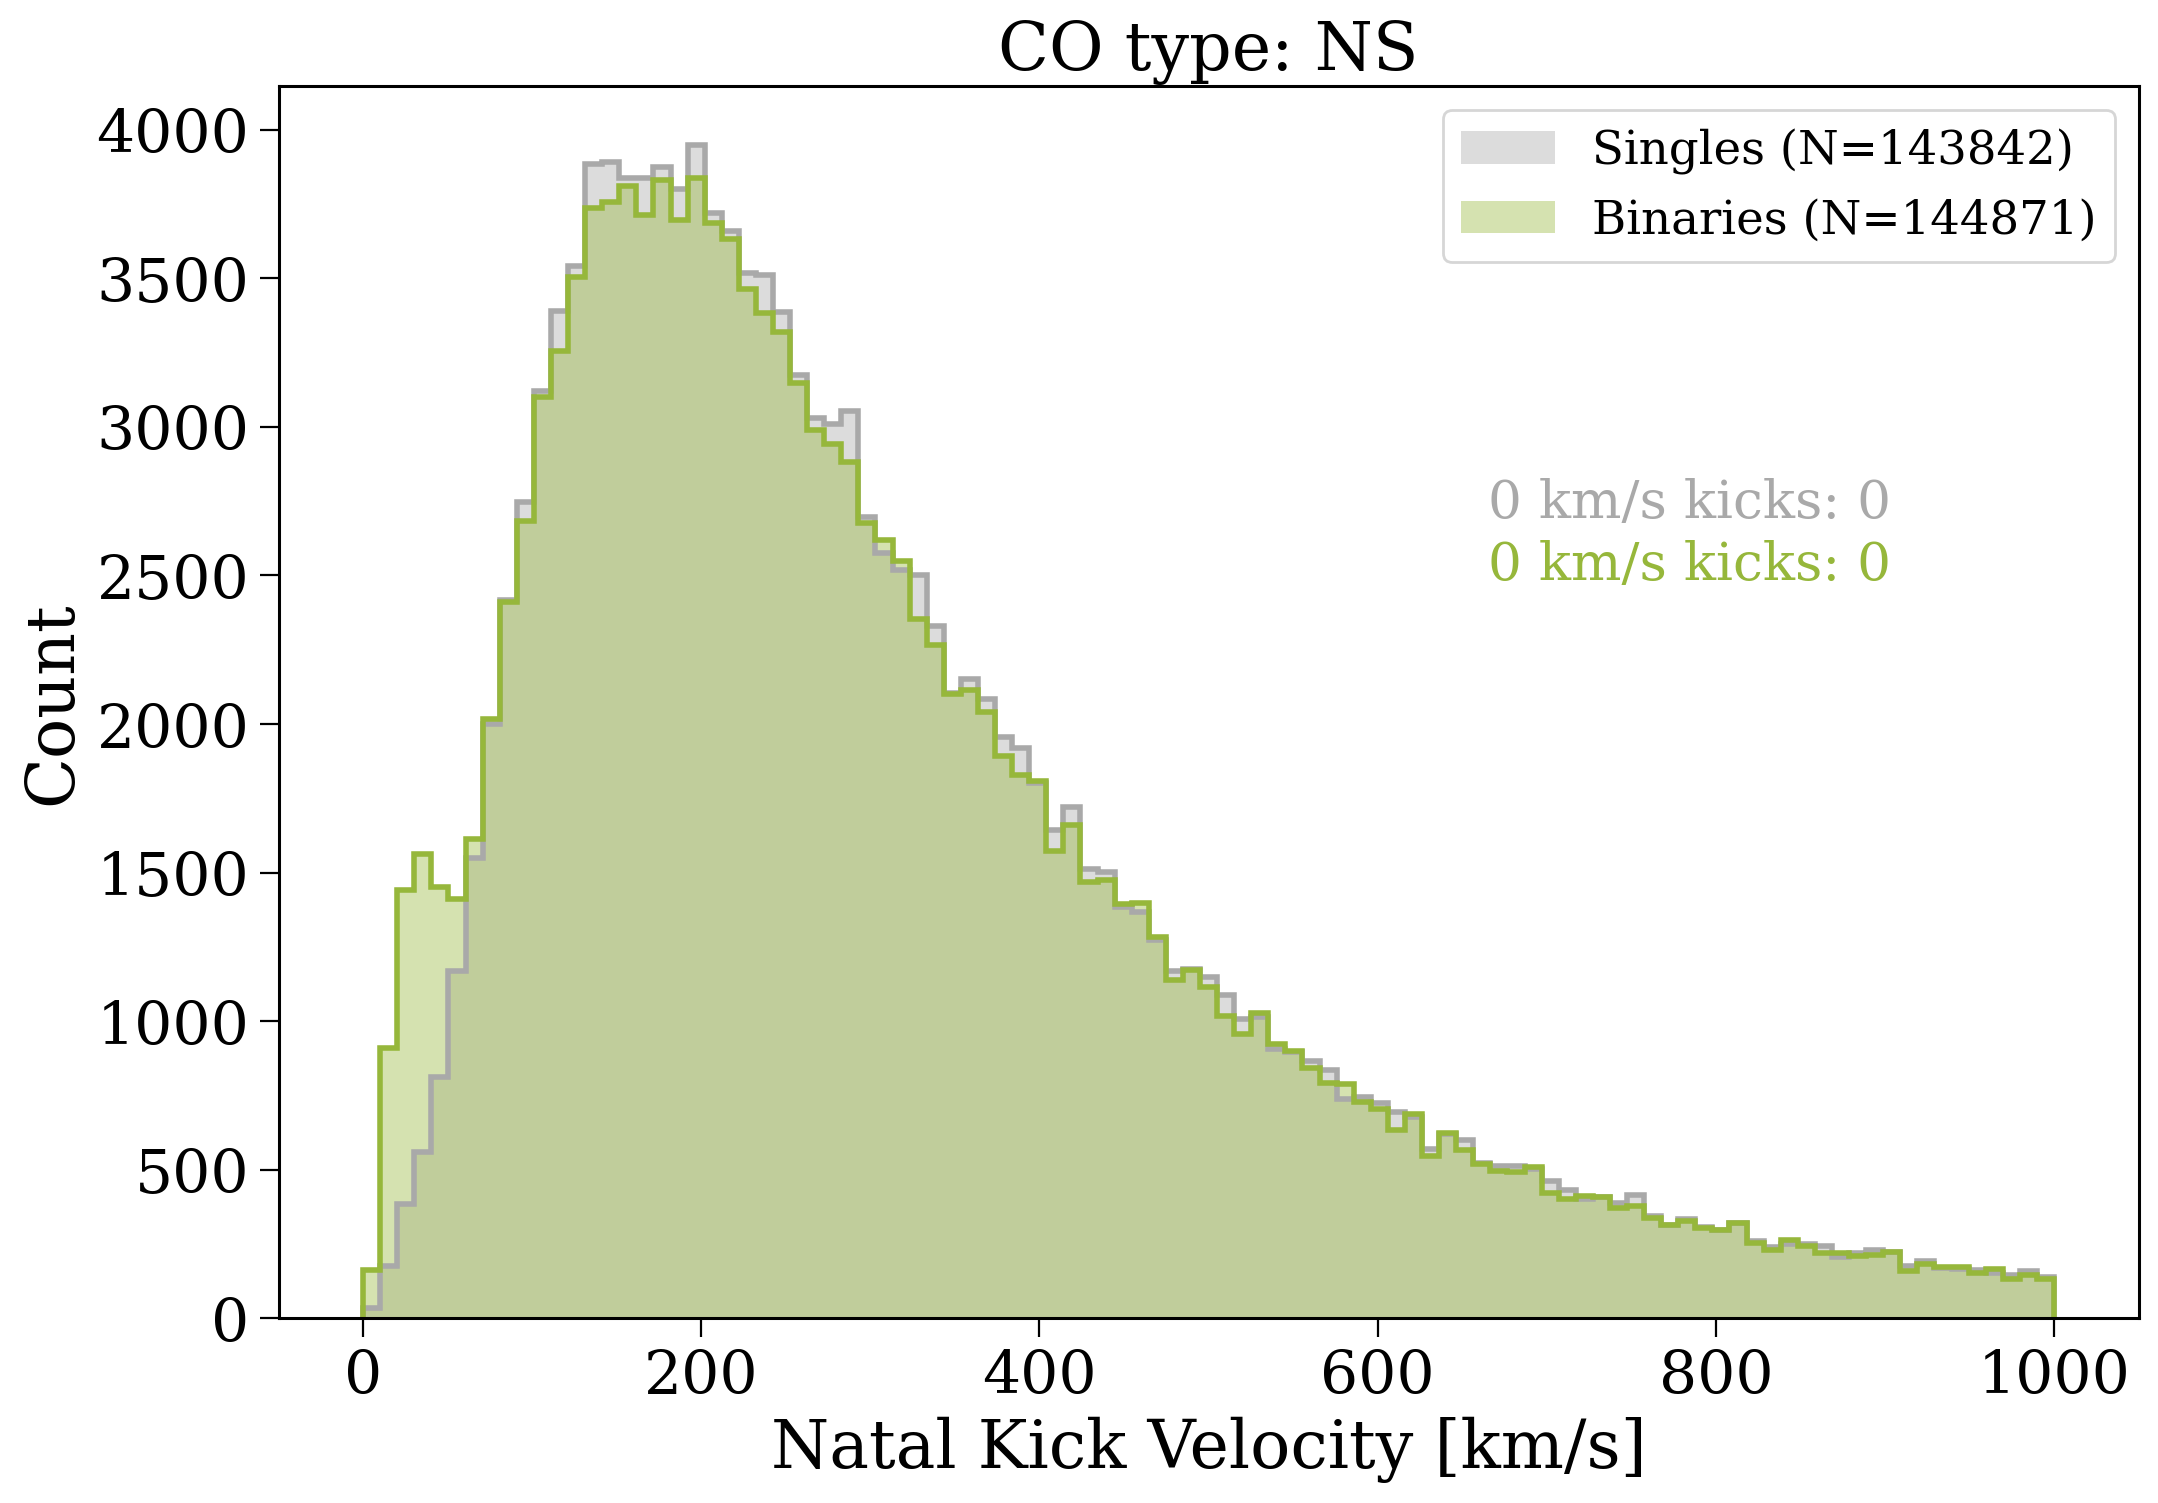

195100
200182


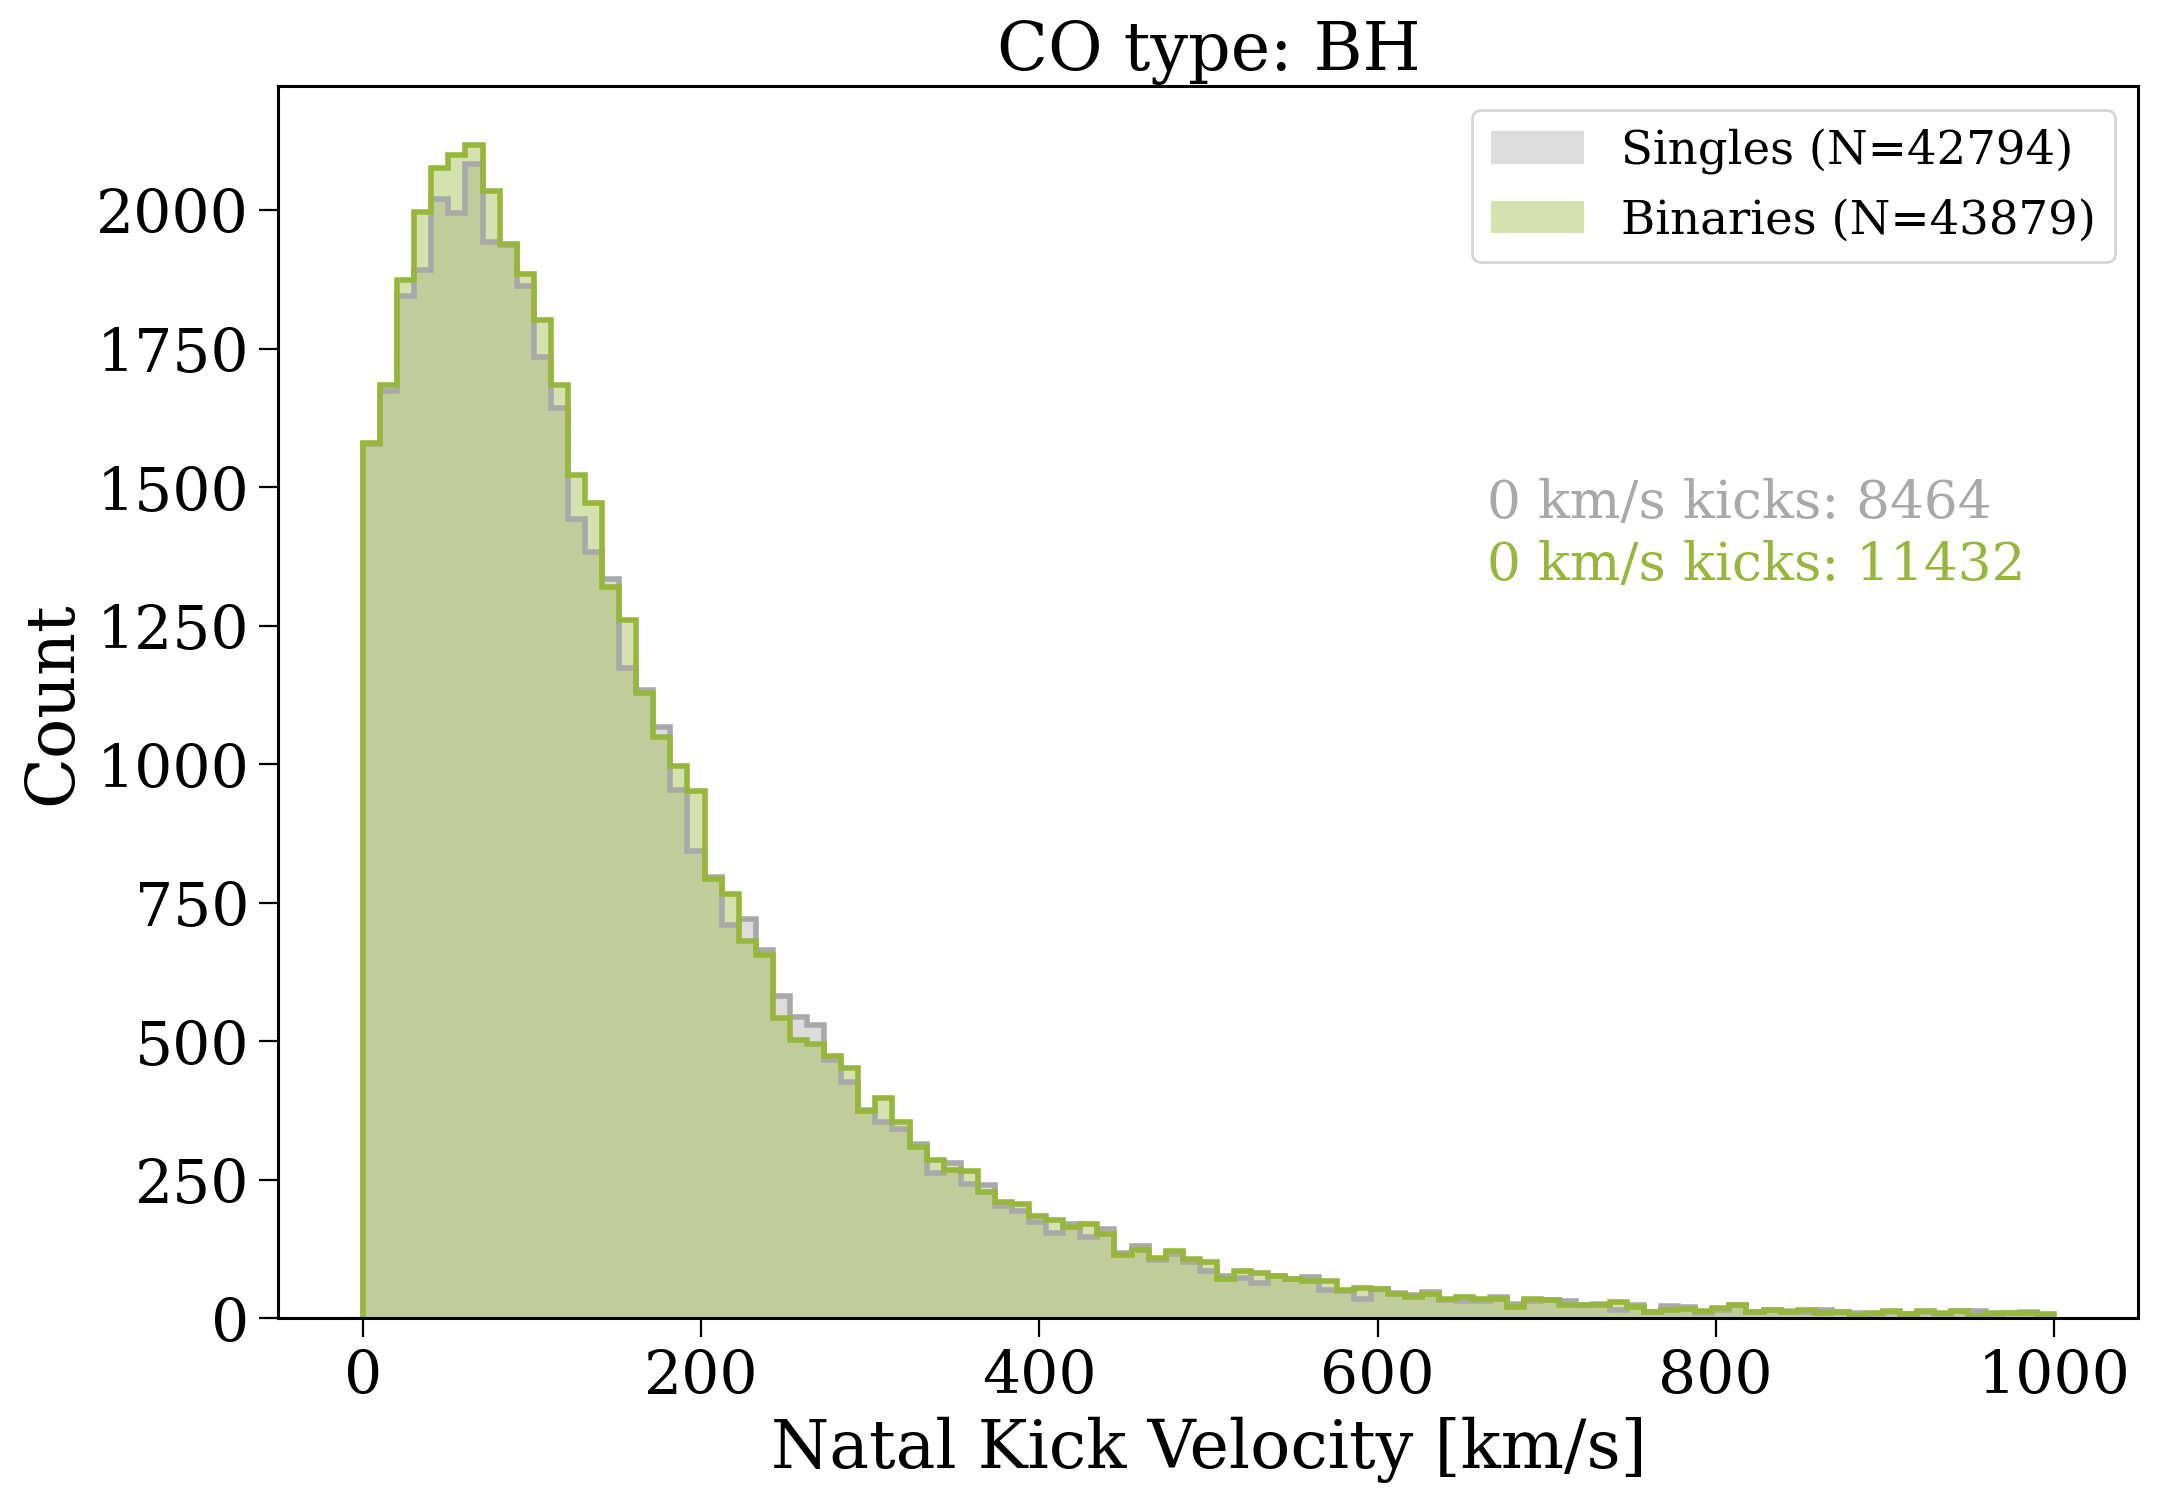

In [32]:
density = False
for co_type_label, co_type in zip(["ALL", "NS", "BH"], [[13, 14], [13], [14]]):

    fig, ax = plt.subplots()

    bins = np.linspace(0, 1000, 100)

    for pop in [singles, binaries]:
        kick_details = pop.kick_info[pop.kick_info["star"] != 0]
        kicks = kick_details["natal_kick"]
        print(len(kicks))

        kick_rows = pop.bpp[pop.bpp["evol_type"].isin([15, 16])]
        after_kick_rows = pop.bpp[pop.bpp["row_num"].isin(kick_rows["row_num"] + 1)]
        kick_co_type = np.where(kick_details["star"] == 1, after_kick_rows["kstar_1"], after_kick_rows["kstar_2"])
        
        kicks = kicks[(np.isin(kick_co_type, co_type))]
        n_zero_kicks = (kicks == 0.0).sum()
        kicks = kicks[(kicks != 0.0)]

        ax.hist(kicks, bins=bins, density=density, histtype='step', lw=2, color=pop.colour)
        ax.hist(kicks, bins=bins, density=density, alpha=0.4, color=pop.colour,
                label=f"{pop.label} (N={len(kicks)})")
        
        ax.annotate(
            f"0 km/s kicks: {n_zero_kicks}",
            xy=(0.65, 0.65 - 0.05 * (0 if pop.label == "Singles" else 1)),
            xycoords='axes fraction',
            color=pop.colour,
            fontsize=0.8*fs,
        )

    ax.set(
        xlabel="Natal Kick Velocity [km/s]",
        ylabel="Count",
    )
    ax.set_title(f"CO type: {co_type_label}", fontsize=fs)
    ax.legend()
    plt.show()

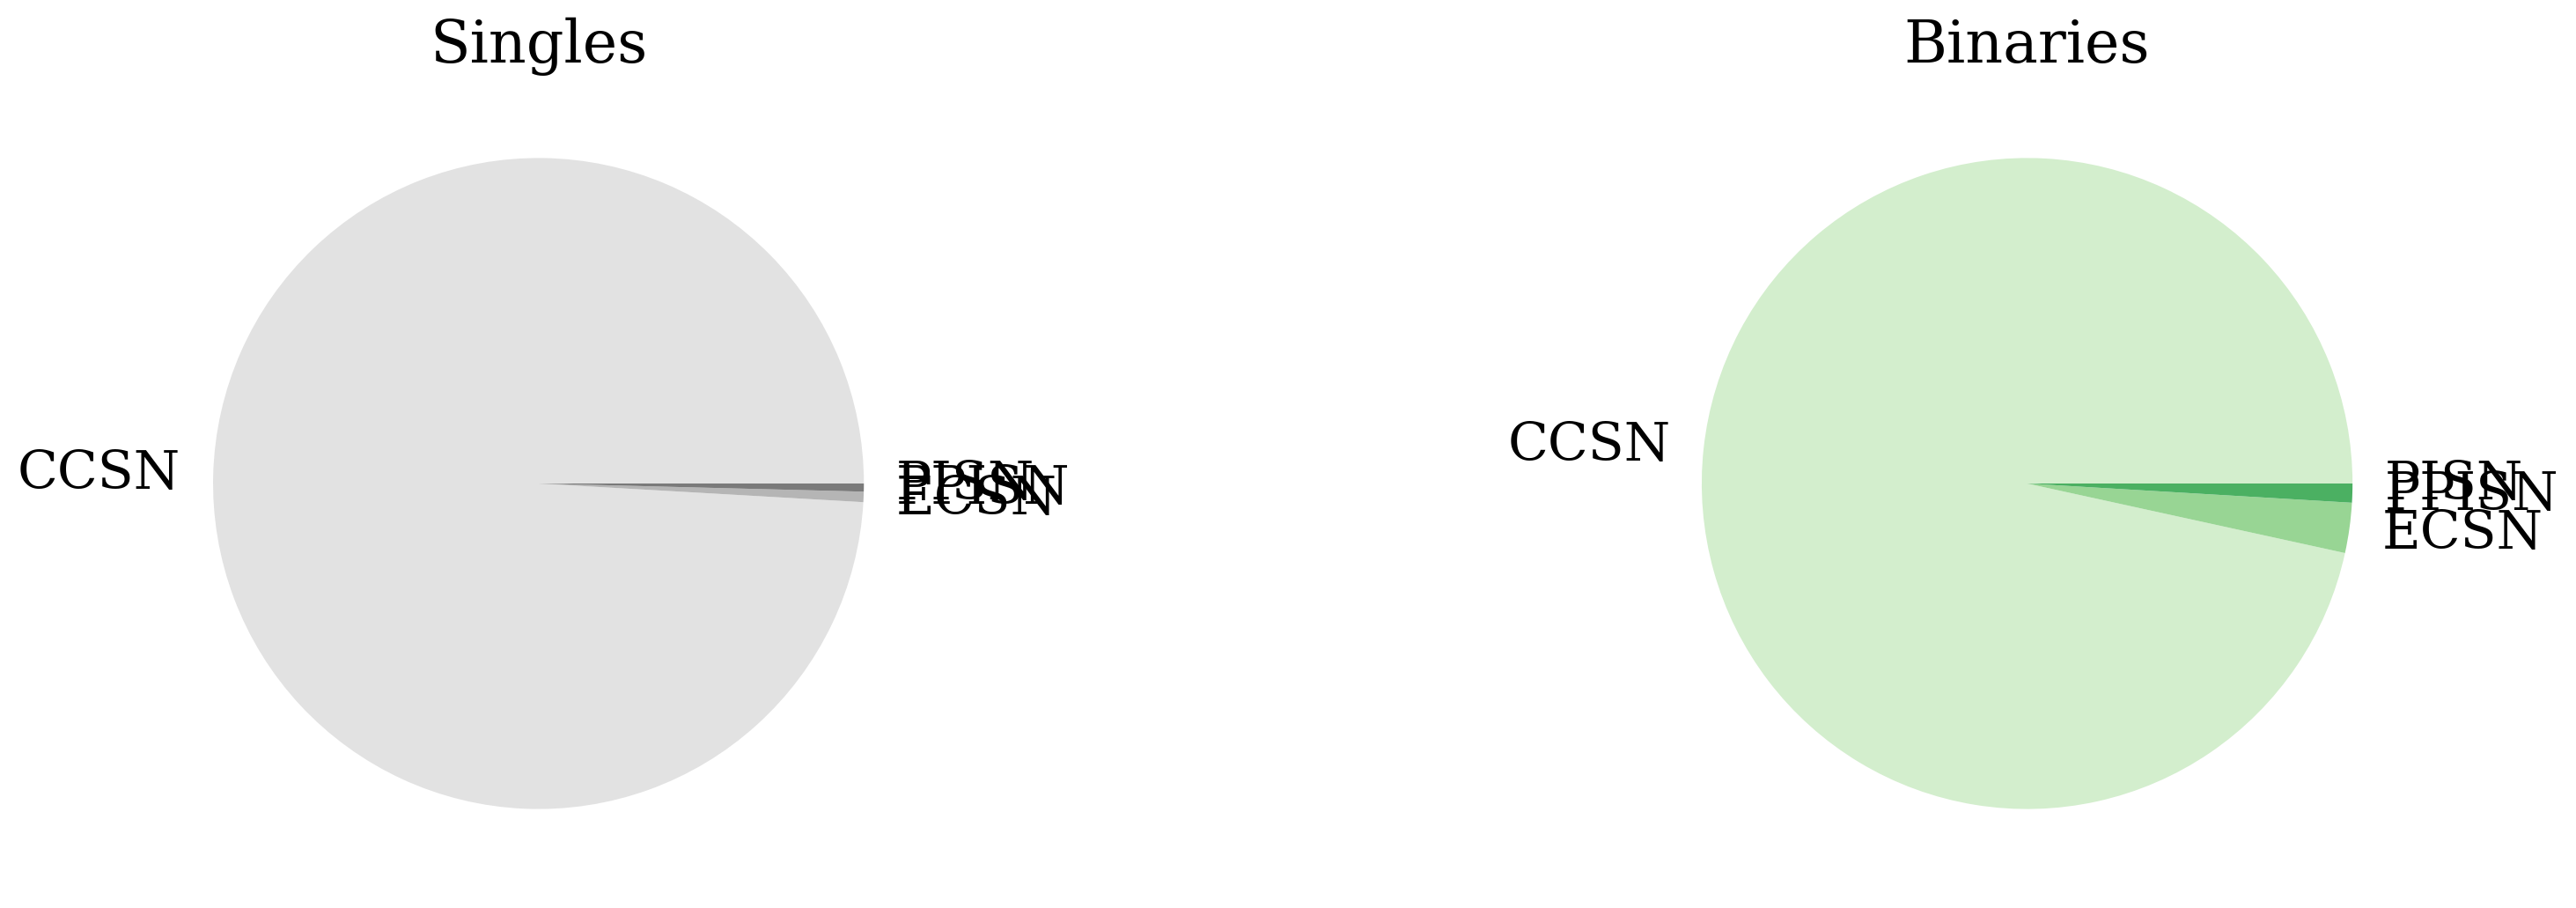

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

for pop, ax in zip([singles, binaries], axes):
    sn_types = np.concatenate((
        pop.final_bpp["SN_1"],
        pop.final_bpp["SN_2"],
    ))
    types, counts = np.unique(sn_types[sn_types > 0], return_counts=True)

    type_label_dict = {
        1: "CCSN",
        2: "ECSN",
        3: "USSN",
        4: "AIC",
        5: "MIC",
        6: "PPISN",
        7: "PISN",
    }

    ax.pie(
        counts,
        labels=[type_label_dict[t] for t in types],
        colors=sns.color_palette("Greens" if pop.label == 'Binaries' else "Greys", n_colors=len(types)),
    )

    ax.set_title(pop.label, fontsize=fs)

0 1 [np.int64(193321), np.int64(194537)]
1 2 [np.int64(1003), np.int64(5008)]
2 6 [np.int64(776), np.int64(1894)]
3 7 [np.int64(2), np.int64(2)]


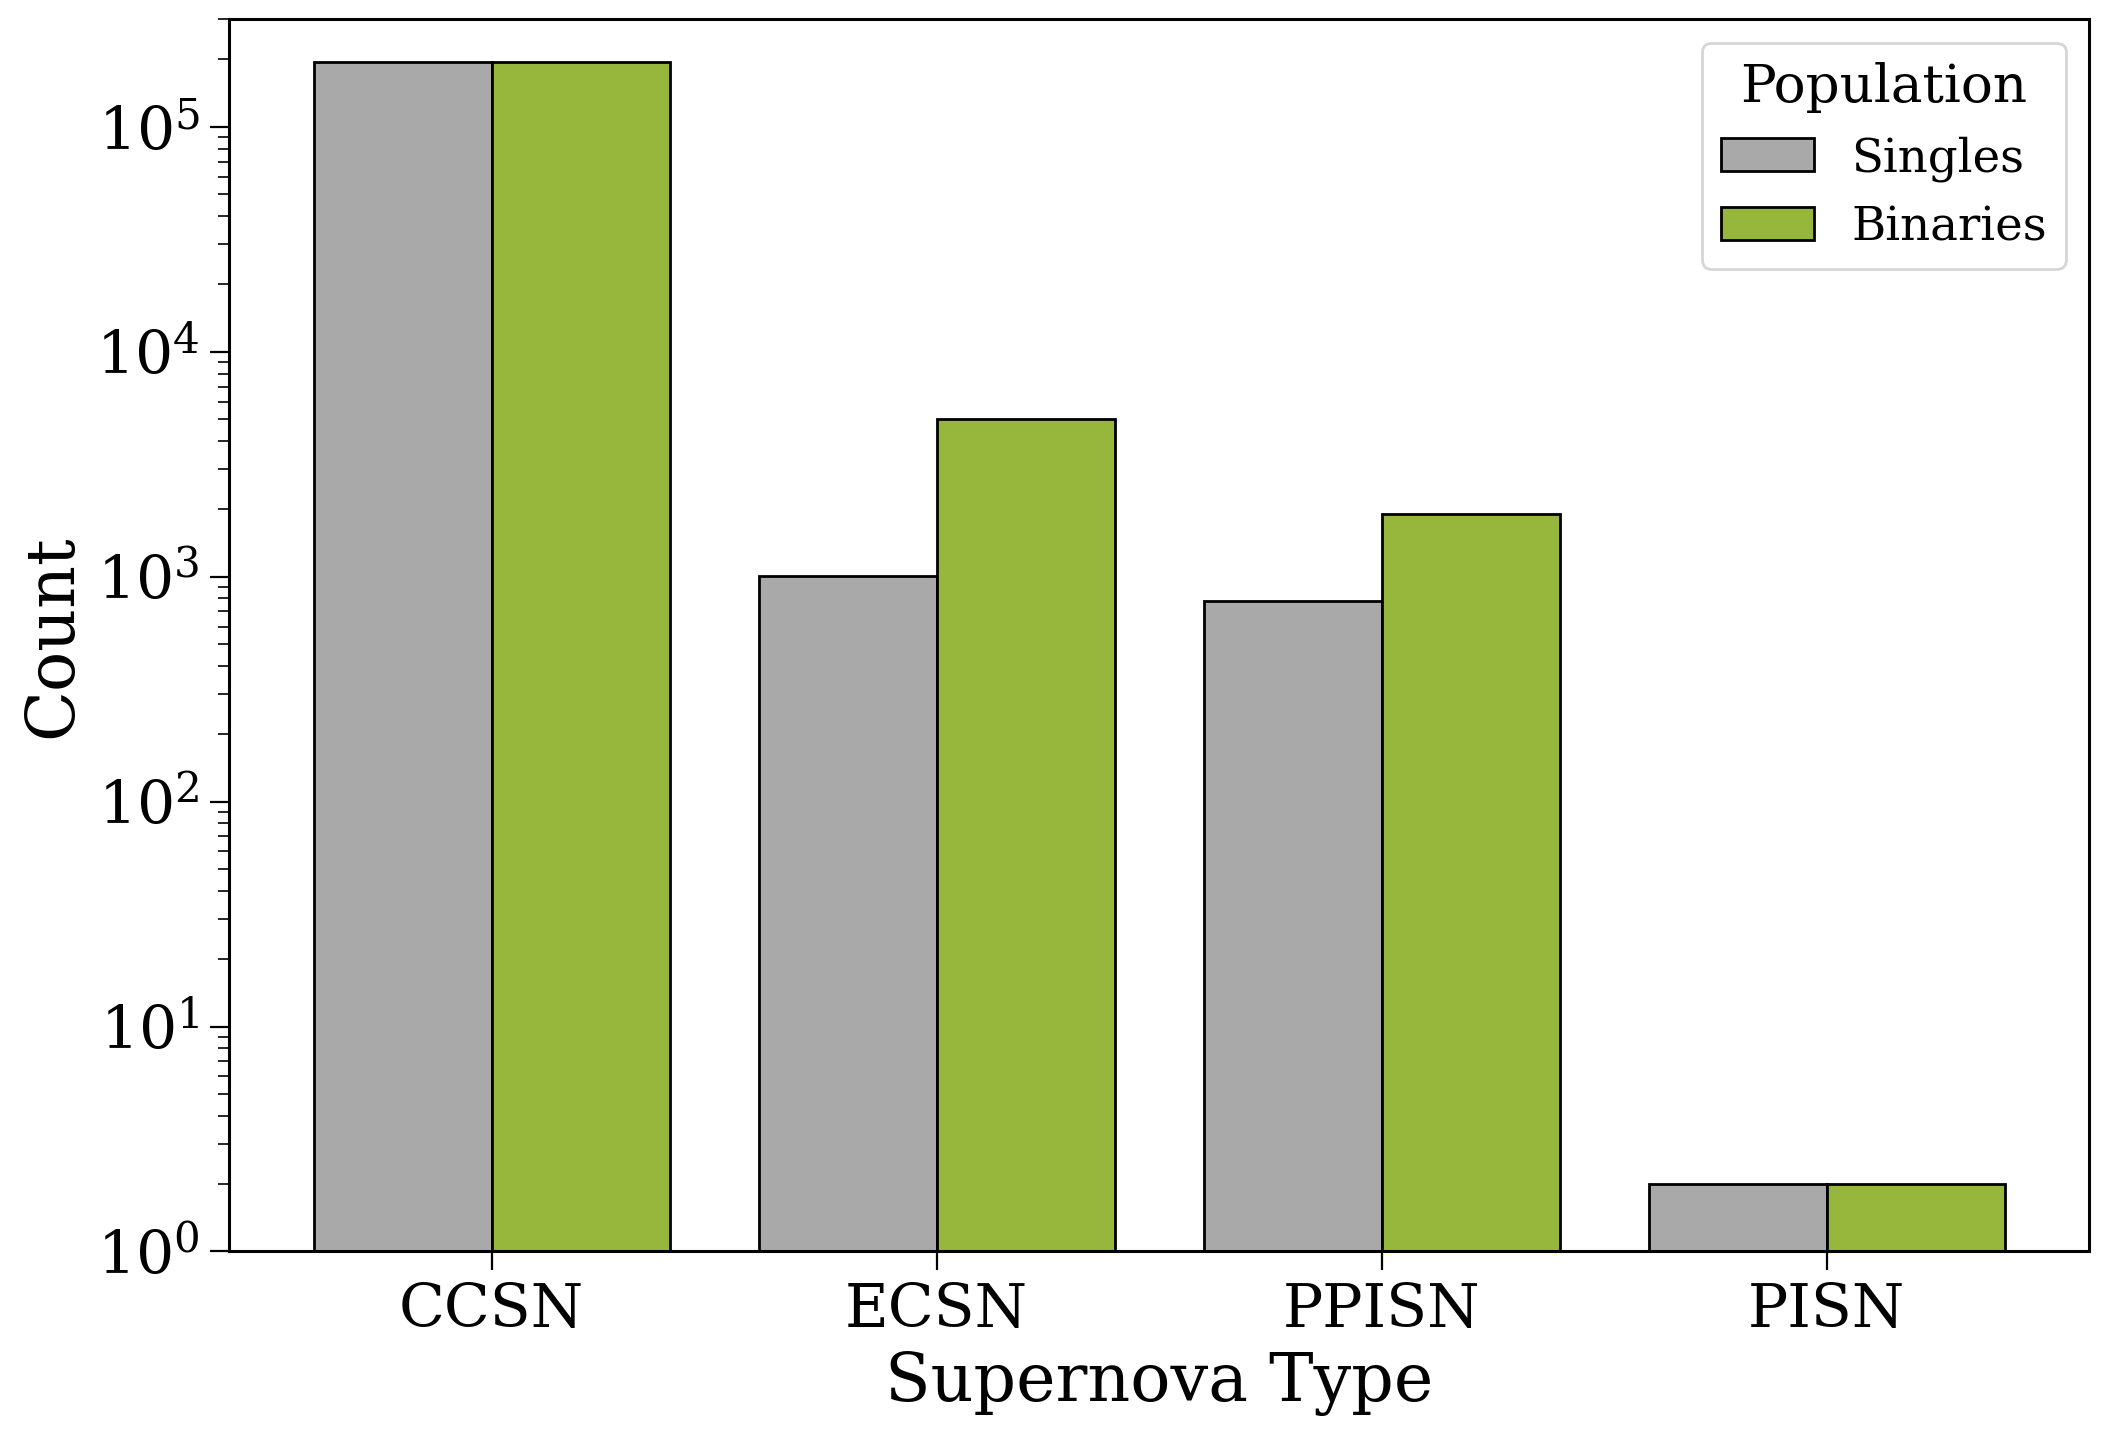

In [34]:
fig, ax = plt.subplots()

count_lists = {
    1: [0, 0],
    2: [0, 0],
    6: [0, 0],
    7: [0, 0],
}
colours = [singles.colour, binaries.colour]

for i, pop in enumerate([singles, binaries]):
    sn_types = np.concatenate((
        pop.final_bpp["SN_1"],
        pop.final_bpp["SN_2"],
    ))
    types, counts = np.unique(sn_types[sn_types > 0], return_counts=True)
    
    for t, c in zip(types, counts):
        count_lists[t][i] = c



type_label_dict = {
    1: "CCSN",
    2: "ECSN",
    3: "USSN",
    4: "AIC",
    5: "MIC",
    6: "PPISN",
    7: "PISN",
}

width = 0.4

for i, (t, counts) in enumerate(count_lists.items()):
    print(i, t, counts)
    ax.bar(i + np.array([-width/2, width/2]), counts, width=width, label=["Singles", "Binaries"] if i == 0 else None, edgecolor='black',
           color=colours)

ax.set_xticks(np.arange(len(count_lists)), [type_label_dict[t] for t in count_lists.keys()])
ax.set_xlabel("Supernova Type")
ax.set_ylabel("Count")
ax.legend(title="Population")

# ax.set_title(pop.label, fontsize=fs)

ax.set(
    ylim=(1e0, 3e5),
    yscale='log',
)

plt.show()

# Initial conditions

## Mass

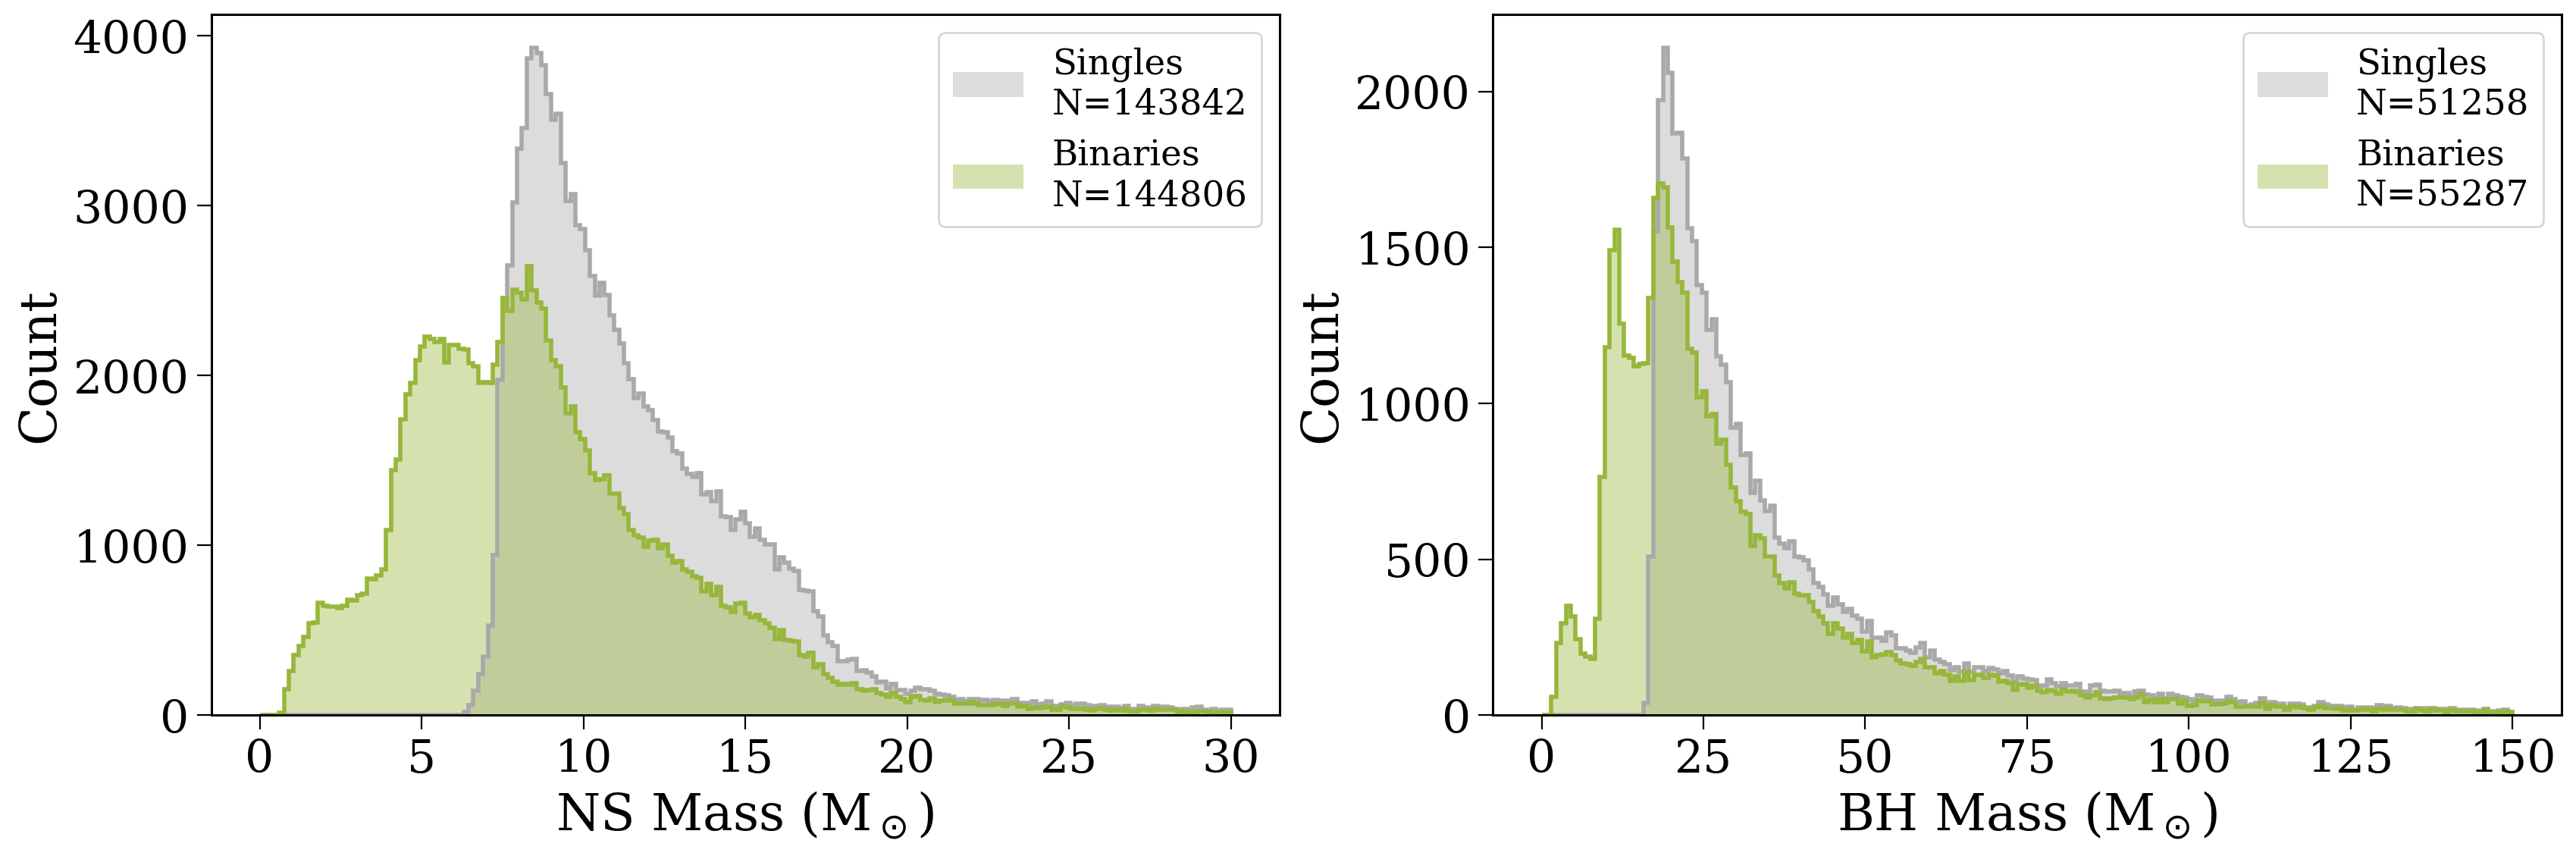

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

for ax, co_type, kstar, bins in zip(axes, ['NS', 'BH'], [13, 14],
                                    [np.linspace(0, 30, 201), np.linspace(0, 150, 201)]):
    plotting.compare_table_quantity(
        pops=[singles, binaries],
        table_name="initC",
        quantity="mass",
        kstar=kstar,
        bins=bins,
        xlabel=f"{co_type} Mass (M$_\odot$)",
        ylabel="Count",
        density=False,
        ax=ax,
        fig=fig,
        show=False
    )
plt.show()

## Metallicity

Worrying spike up at $Z = 0.03$

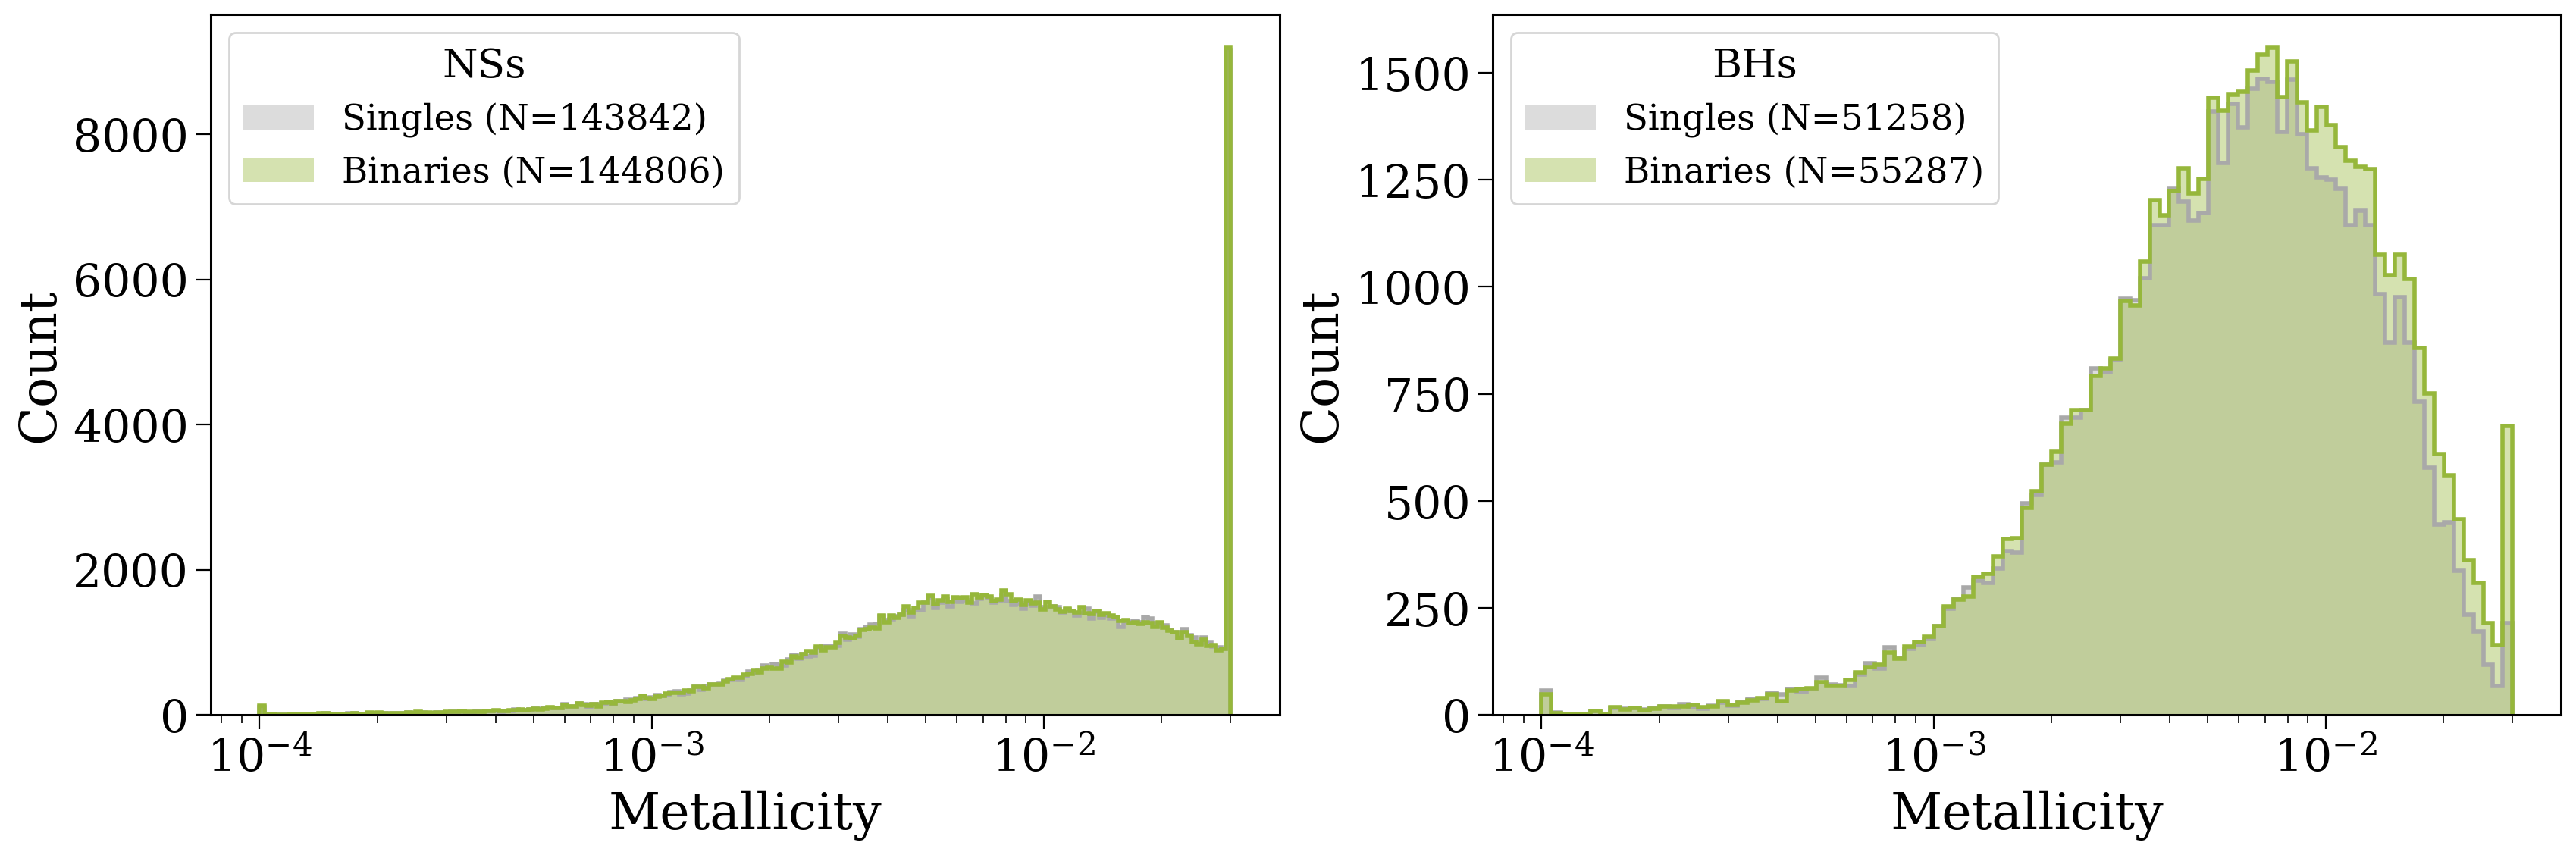

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

for ax, co_type, kstar, bins in zip(axes, ['NS', 'BH'], [13, 14],
                                    [np.geomspace(1e-4, 0.03, 200), np.geomspace(1e-4, 0.03, 100)]):
    for pop in [singles, binaries]:
        init_Z = np.concatenate((
            pop.initC["metallicity"][pop.final_bpp["kstar_1"] == kstar],
            pop.initC["metallicity"][pop.final_bpp["kstar_2"] == kstar]
        ))

        ax.hist(init_Z, bins=bins, histtype='step', lw=2, color=pop.colour)
        ax.hist(init_Z, bins=bins, alpha=0.4, color=pop.colour,
                label=f"{pop.label} (N={len(init_Z)})")

    ax.set(
        xlabel=f"Metallicity",
        ylabel="Count",
        xscale='log'
    )
    ax.legend(title=f"{co_type}s")
plt.show()

## Formation time

Basically no change on galactic scales

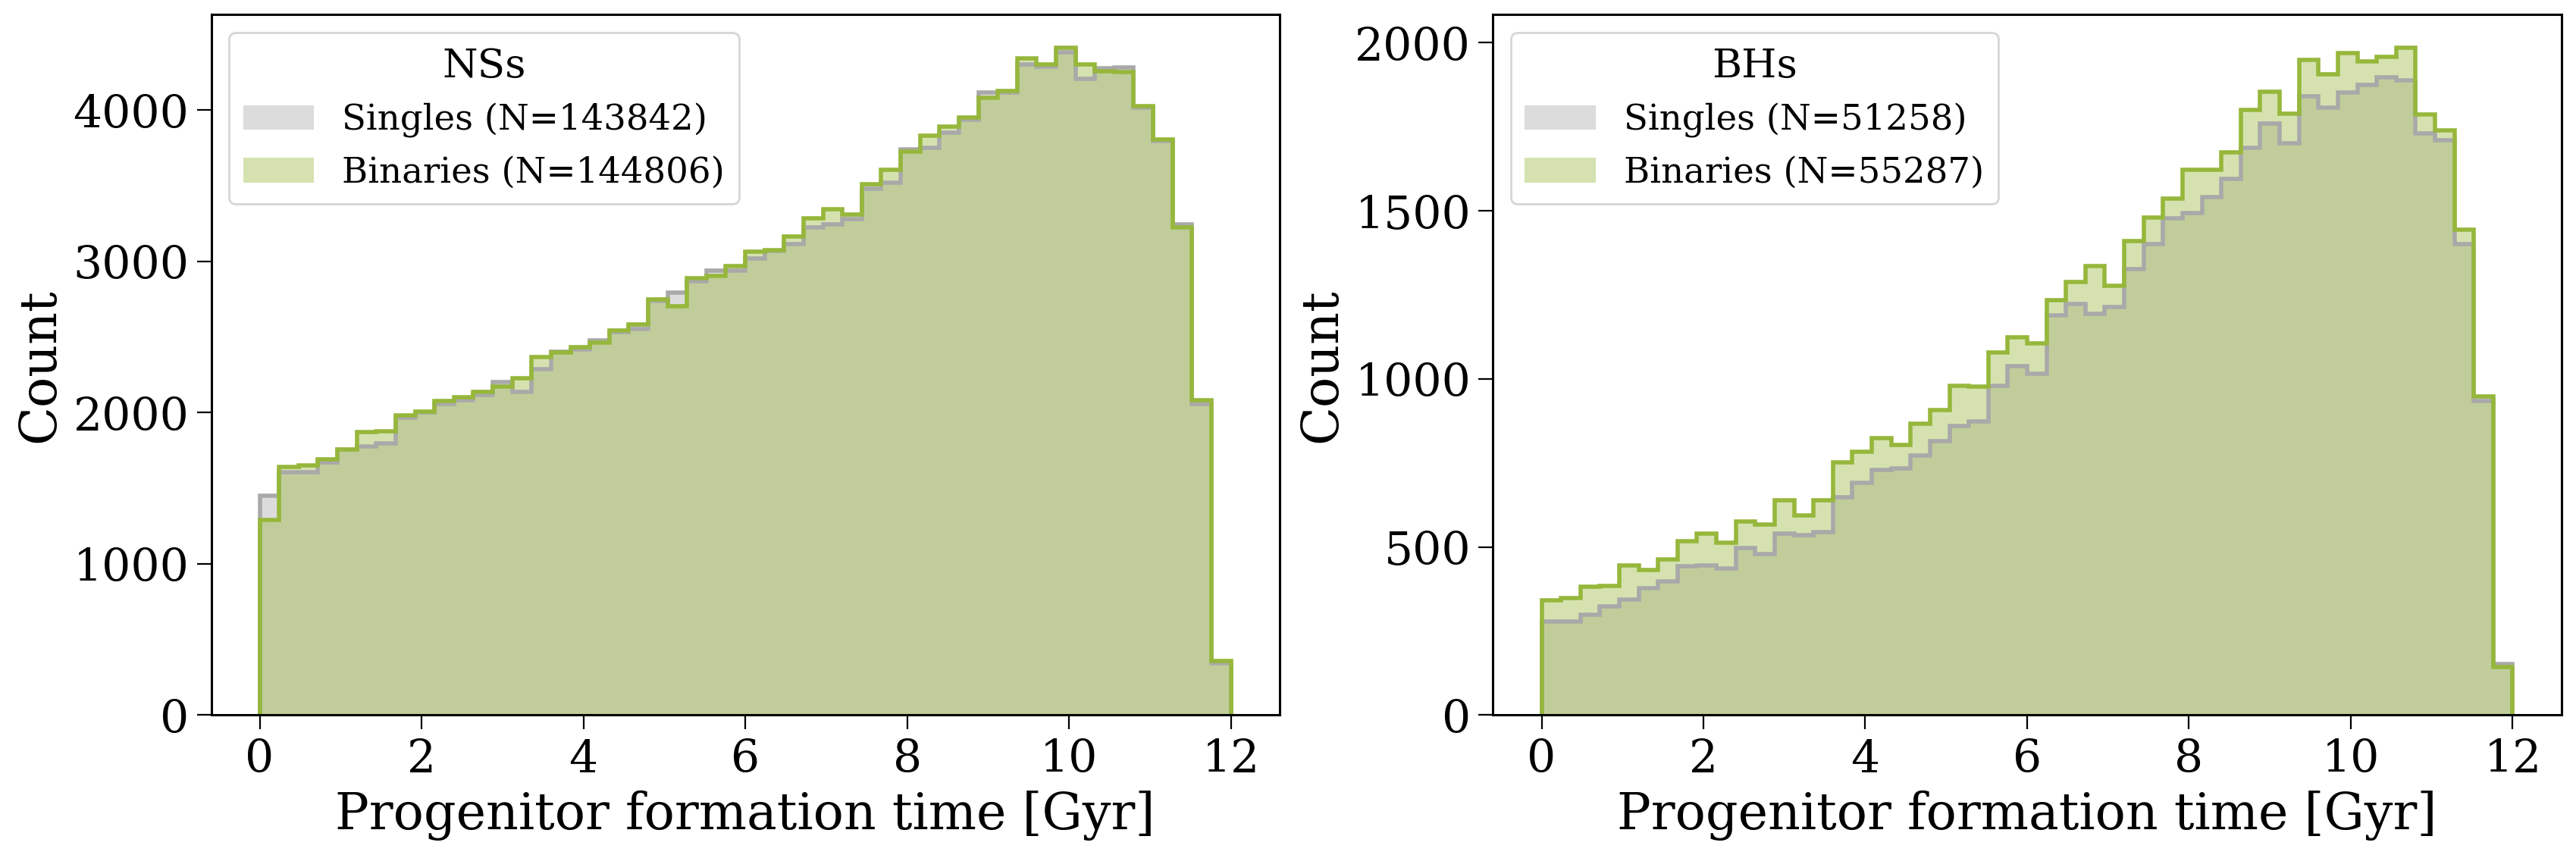

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

for ax, co_type, kstar, bins in zip(axes, ['NS', 'BH'], [13, 14],
                                    [np.linspace(0, 12, 51), np.linspace(0, 12, 51)]):
    for pop in [singles, binaries]:
        tau = pd.read_hdf(pop._file, "initial_galaxy")["tau"].values
        formation_time = np.concatenate((
            tau[pop.final_bpp["kstar_1"] == kstar],
            tau[pop.final_bpp["kstar_2"] == kstar]
        ))

        ax.hist(formation_time, bins=bins, histtype='step', lw=2, color=pop.colour)
        ax.hist(formation_time, bins=bins, alpha=0.4, color=pop.colour,
                label=f"{pop.label} (N={len(formation_time)})")

    ax.set(
        xlabel=f"Progenitor formation time [Gyr]",
        ylabel="Count"
    )
    ax.legend(title=f"{co_type}s")
plt.show()

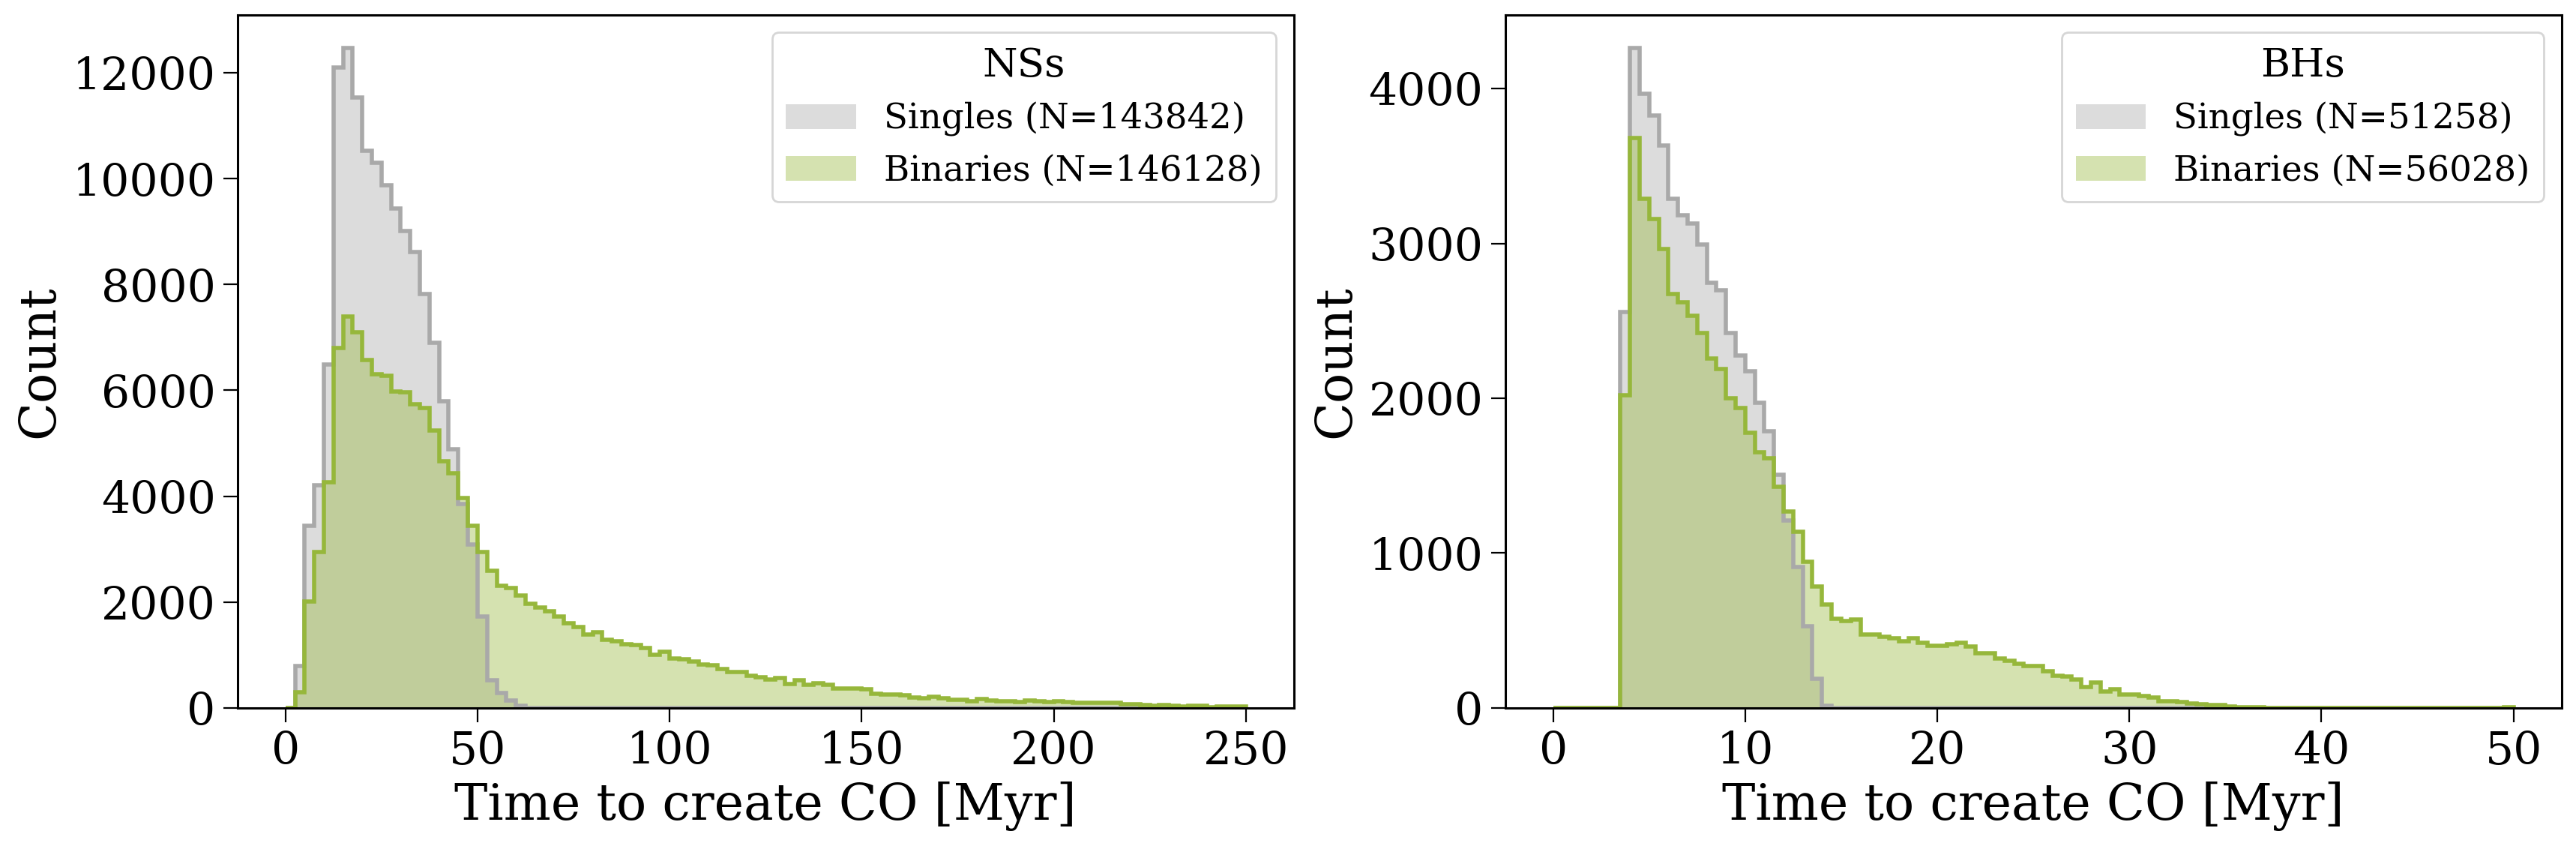

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

for ax, co_type, kstar, bins in zip(axes, ['NS', 'BH'], [13, 14],
                                    [np.linspace(0, 250, 101), np.linspace(0, 50, 101)]):
    for pop in [singles, binaries]:
        co_form_time = np.concatenate((
            pop.bpp[pop.bpp["kstar_1"] == kstar].drop_duplicates(subset="bin_num", keep="first")["tphys"].values,
            pop.bpp[pop.bpp["kstar_2"] == kstar].drop_duplicates(subset="bin_num", keep="first")["tphys"].values,
        ))

        ax.hist(co_form_time, bins=bins, histtype='step', lw=2, color=pop.colour)
        ax.hist(co_form_time, bins=bins, alpha=0.4, color=pop.colour,
                label=f"{pop.label} (N={len(co_form_time)})")

    ax.set(
        xlabel=f"Time to create CO [Myr]",
        ylabel="Count"
    )
    ax.legend(title=f"{co_type}s")
plt.show()

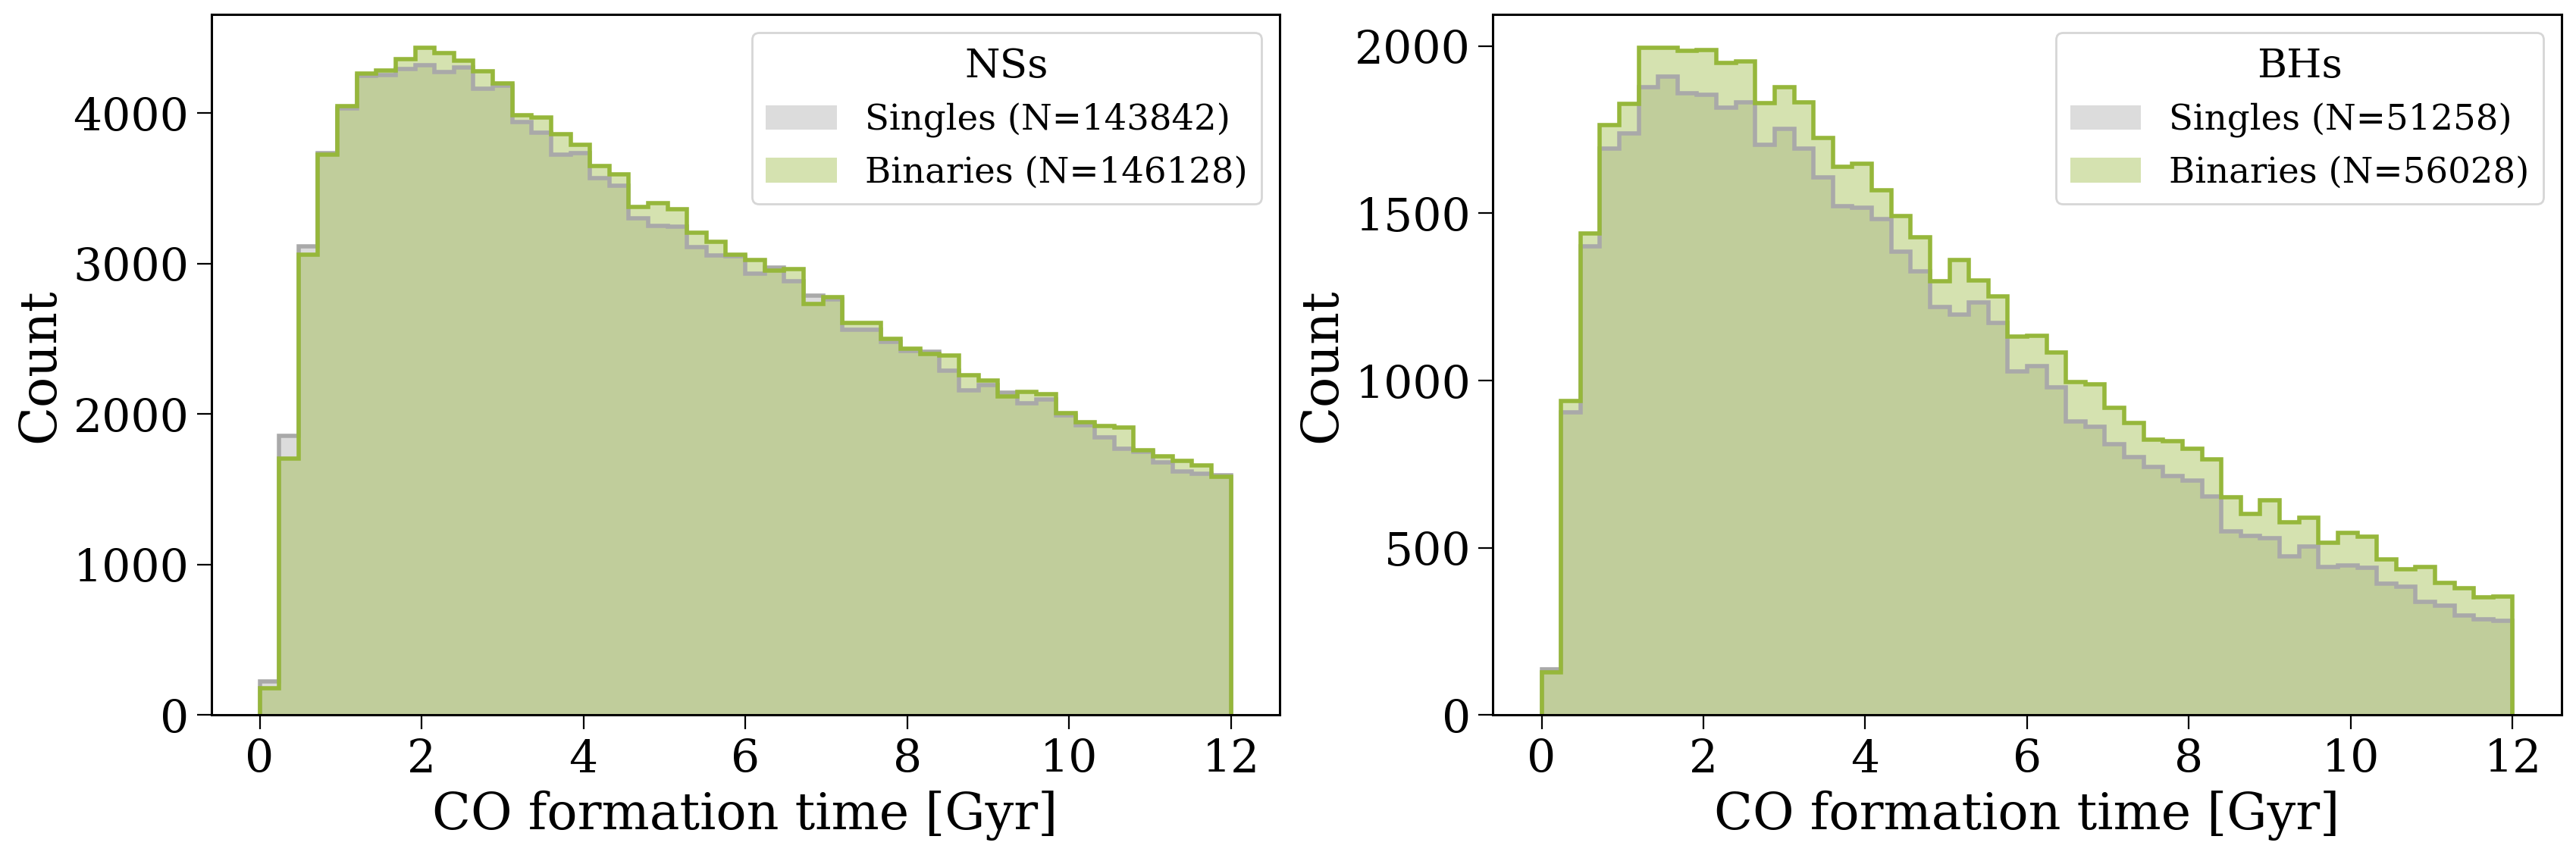

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

for ax, co_type, kstar, bins in zip(axes, ['NS', 'BH'], [13, 14],
                                    [np.linspace(0, 12, 51), np.linspace(0, 12, 51)]):
    for pop in [singles, binaries]:
        initial_galaxy = pd.read_hdf(pop._file, "initial_galaxy")
        initial_galaxy.index = pop.bin_nums
        co_form_time = np.concatenate((
            pop.bpp[pop.bpp["kstar_1"] == kstar].drop_duplicates(subset="bin_num", keep="first")["tphys"].values,
            pop.bpp[pop.bpp["kstar_2"] == kstar].drop_duplicates(subset="bin_num", keep="first")["tphys"].values,
        ))
        co_form_nums = np.concatenate((
            pop.bpp[pop.bpp["kstar_1"] == kstar].drop_duplicates(subset="bin_num", keep="first")["bin_num"].values,
            pop.bpp[pop.bpp["kstar_2"] == kstar].drop_duplicates(subset="bin_num", keep="first")["bin_num"].values,
        ))
        lookback_times = initial_galaxy.loc[co_form_nums]["tau"].values
        galaxy_age = 12

        time_of_co_formation = galaxy_age - lookback_times + co_form_time / 1000

        ax.hist(time_of_co_formation, bins=bins, histtype='step', lw=2, color=pop.colour)
        ax.hist(time_of_co_formation, bins=bins, alpha=0.4, color=pop.colour,
                label=f"{pop.label} (N={len(time_of_co_formation)})")

    ax.set(
        xlabel=f"CO formation time [Gyr]",
        ylabel="Count"
    )
    ax.legend(title=f"{co_type}s")
plt.show()

## Galactic component

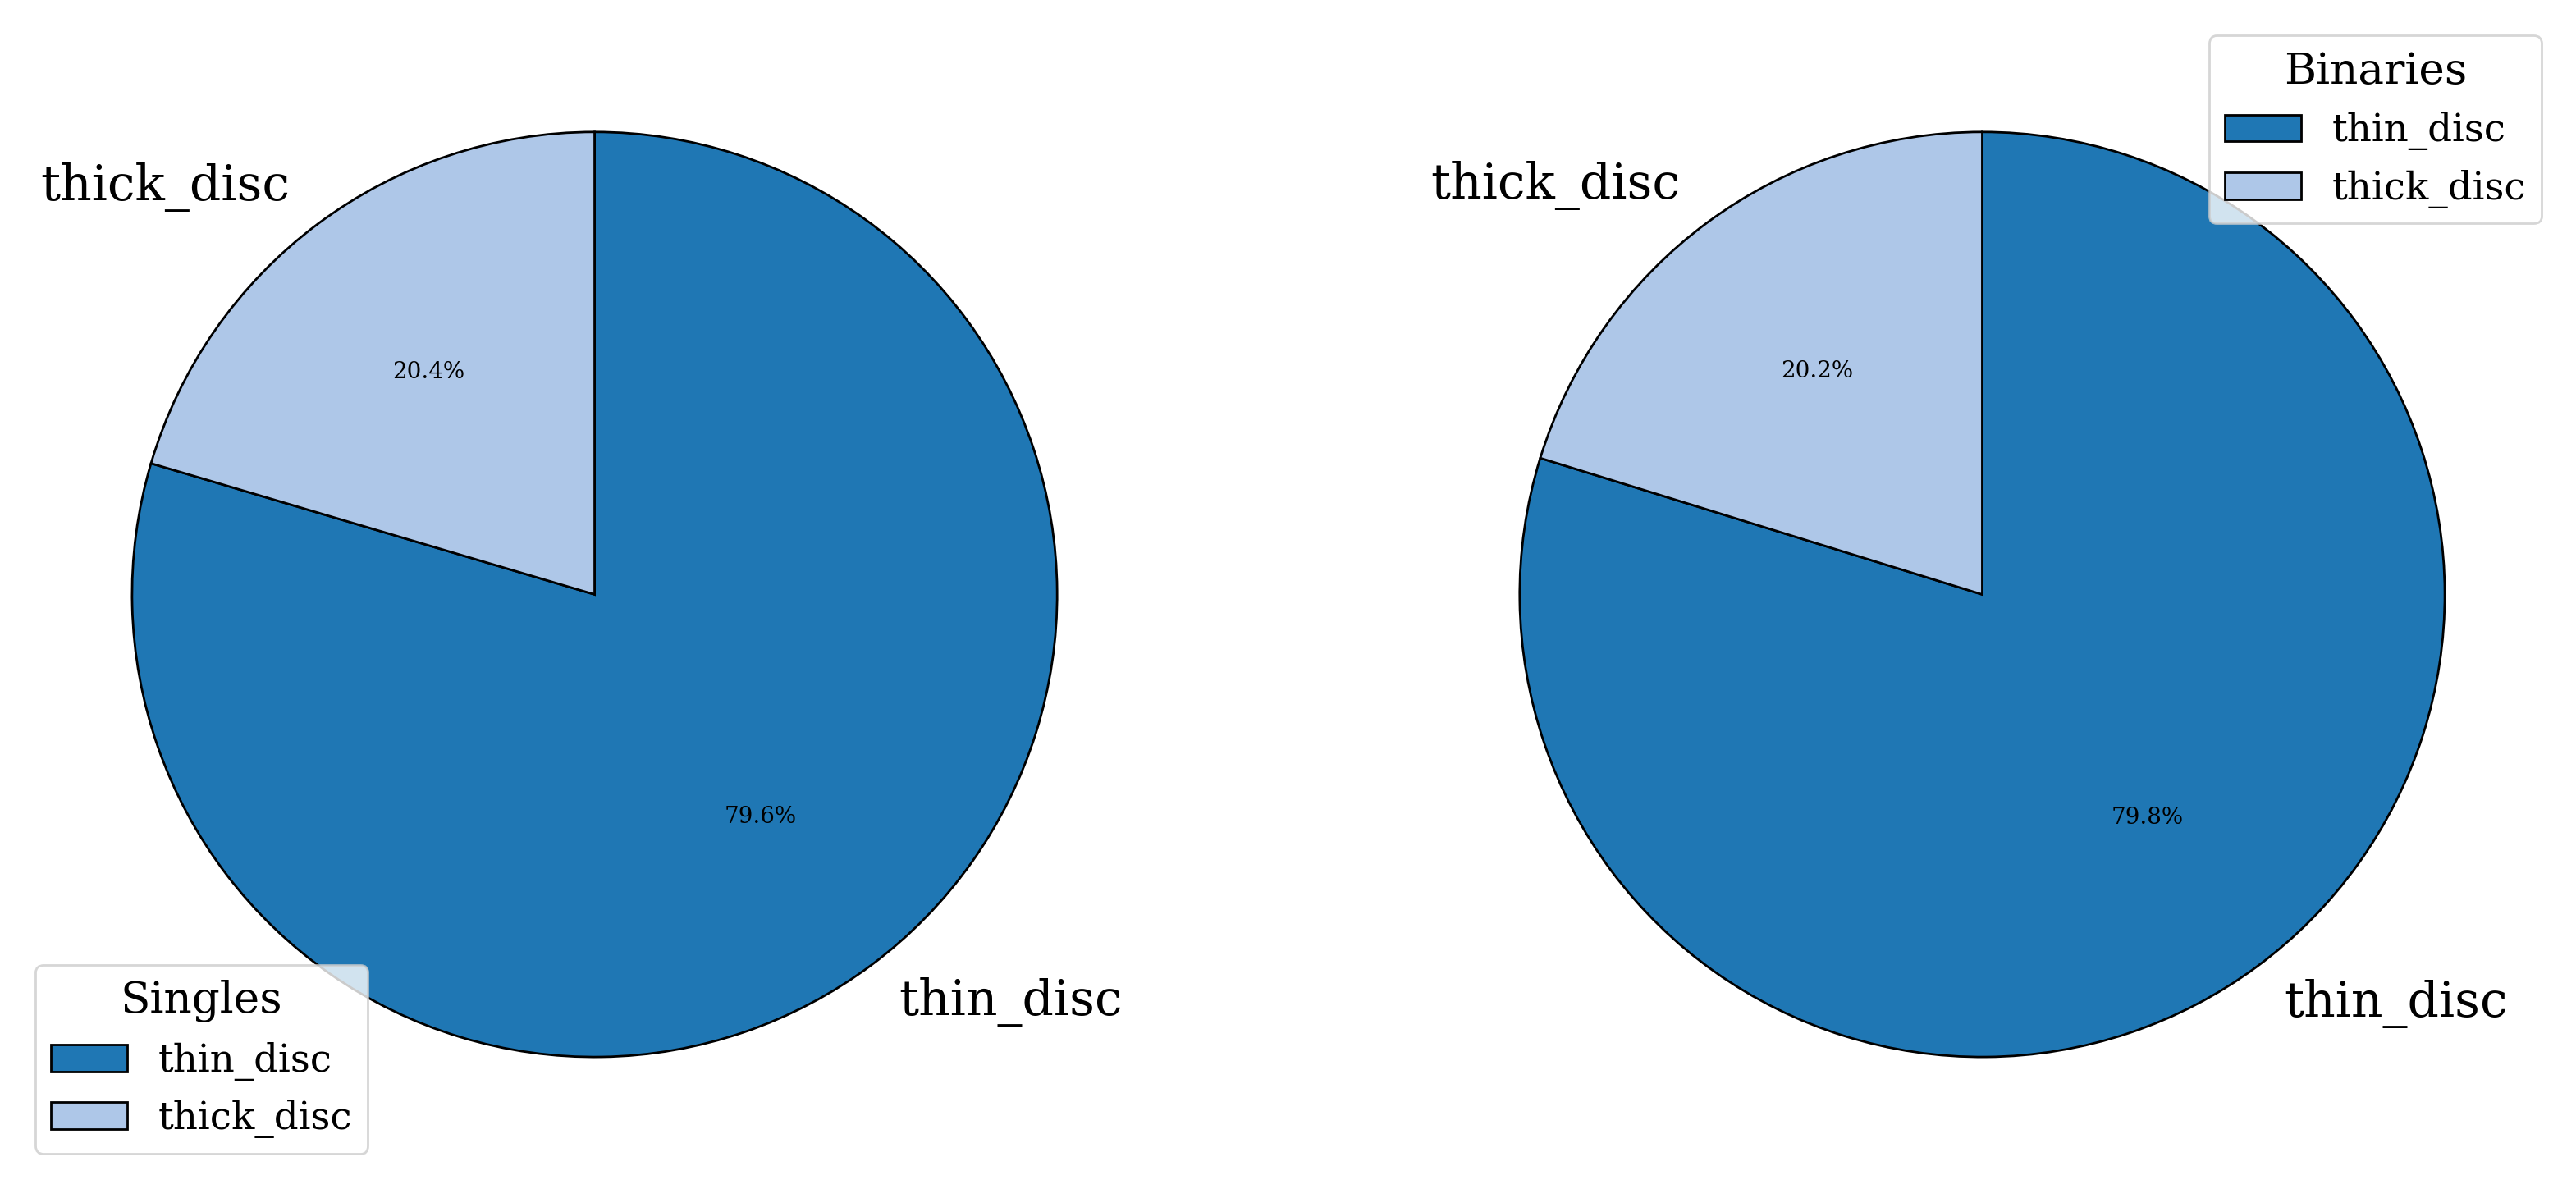

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

for ax, pop in zip(axes, [singles, binaries]):
    initial_galaxy = pd.read_hdf(pop._file, "initial_galaxy")
    initial_galaxy.index = pop.bin_nums
    co_form_nums = np.concatenate((
        pop.bpp[pop.bpp["kstar_1"].isin([13, 14])].drop_duplicates(subset="bin_num", keep="first")["bin_num"].values,
        pop.bpp[pop.bpp["kstar_2"].isin([13, 14])].drop_duplicates(subset="bin_num", keep="first")["bin_num"].values,
    ))
    
    ax.pie(
        initial_galaxy.loc[co_form_nums]["which_comp"].value_counts().values,
        labels=initial_galaxy.loc[co_form_nums]["which_comp"].value_counts().index,
        autopct='%1.1f%%',
        colors=mpl.colormaps['tab20'].colors,
        startangle=90,
        counterclock=False,
        wedgeprops={'edgecolor': 'black'}
    )
    ax.legend(title=f"{pop.label}")
plt.show()